# 01 Imports, Model Definitions, Training

The name Mo2BERTa is a post-train naming, so in this notebook that model is still being called as MoR-BERT.

by hf:@gbyuvd

# OPT1 PADDED SDPA CALL -> WALL CLOCK

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
import math
from tqdm import tqdm
from collections import defaultdict
import json
from enum import Enum
from typing import Optional

# ==========================================================
# CONFIGURATION
# ==========================================================
TOKENIZER_NAME   = "bert-base-uncased"  
DIM              = 256
N_RECURSION      = 4      # Deliberately high on tiny shared block to force routing to learn
N_LAYERS         = 4      # Unique first + (N_LAYERS-2) shared middle + unique last
N_HEADS          = 8
N_KV_HEADS       = 4      # GQA: 2:1 head ratio
MLP_HIDDEN_DIM   = 512
CONTEXT_LEN      = 128
BATCH_SIZE       = 8
MAX_STEPS        = 500
EVAL_INTERVAL    = 100
LR               = 3e-4
AUX_LOSS_WEIGHT  = 0.1
MASK_FRACTION    = 0.15
MAX_TFLOPS = 600e12          # 600 TFLOP hardcap for all models
EVAL_TFLOPS_INTERVAL = 50e12  # Validate every 50 TFLOPs
TOKENS_PER_STEP = BATCH_SIZE * CONTEXT_LEN  # For tracking D

class MoRPhase(Enum):
    BASELINE  = 0   # all tokens, all ops; establishes upper-bound loss
    FULL_SKIP = 1   # gather-scatter for both attn QKV and MLP

torch.cuda.empty_cache()

try:
    from transformers import AutoTokenizer
    HAS_TRANSFORMERS = True
except ImportError:
    HAS_TRANSFORMERS = False
    print("WARNING: pip install transformers")

try:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

torch.manual_seed(42)
np.random.seed(42)

# ==========================================================
# 1. DATASET
# ==========================================================
class MLMTextDataset:
    def __init__(self, tokenizer, filepath="input.txt",
                 context_len=128, batch_size=32,
                 val_split=0.1, data_fraction=1.0):
        self.context_len    = context_len
        self.batch_size     = batch_size
        self.tokenizer      = tokenizer
        self.vocab_size     = tokenizer.vocab_size
        self.mask_token_id  = tokenizer.mask_token_id
        self.pad_token_id   = tokenizer.pad_token_id or 0

        if not os.path.exists(filepath):
            print("  input.txt not found - generating dummy text...")
            dummy = ("To be or not to be, that is the question. " * 5000 +
                     "Whether 'tis nobler in the mind to suffer " * 2000 +
                     "The slings and arrows of outrageous fortune, " * 2000)
            with open(filepath, "w") as f:
                f.write(dummy)

        with open(filepath, "r", encoding="utf-8") as f:
            full_text = f.read()

        if data_fraction < 1.0:
            chunk_size = 2048
            num_chunks = len(full_text) // chunk_size
            if num_chunks > 1:
                indices = list(range(num_chunks))
                np.random.shuffle(indices)
                n_take = max(1, int(num_chunks * data_fraction))
                selected = sorted(indices[:n_take])
                full_text = "".join(
                    full_text[idx * chunk_size: (idx + 1) * chunk_size]
                    for idx in selected
                )

        print("  Tokenizing...", end=" ", flush=True)
        chunk_size_tok = 50_000
        token_ids = []
        for start in range(0, len(full_text), chunk_size_tok):
            ids = tokenizer.encode(
                full_text[start: start + chunk_size_tok],
                add_special_tokens=False,
                max_length=512,
                truncation=True
            )
            token_ids.extend(ids)
        print(f"done. {len(token_ids):,} tokens")

        self.encoded    = torch.tensor(token_ids, dtype=torch.long)
        n               = len(self.encoded)
        train_n         = int(n * (1 - val_split))
        self.train_data = self.encoded[:train_n]
        self.val_data   = self.encoded[train_n:]
        print(f"  Train: {len(self.train_data):,} | Val: {len(self.val_data):,}")

    def mask_batch(self, x):
        """BERT-style MLM: 80% [MASK], 10% random, 10% unchanged."""
        inputs = x.clone()
        labels = torch.full_like(x, -100)

        rand           = torch.rand(x.shape, device=x.device)
        mask_positions = rand < MASK_FRACTION

        rand2                    = torch.rand(x.shape, device=x.device)
        mask_token_pos           = mask_positions & (rand2 < 0.8)
        random_token_pos         = mask_positions & (rand2 >= 0.8) & (rand2 < 0.9)

        inputs[mask_token_pos]   = self.mask_token_id
        random_tokens            = torch.randint(0, self.vocab_size, x.shape, device=x.device)
        inputs[random_token_pos] = random_tokens[random_token_pos]
        labels[mask_positions]   = x[mask_positions]

        return inputs, labels

    def get_train_batches(self, device):
        max_idx = len(self.train_data) - self.context_len - 1
        indices = torch.randperm(max_idx)
        for i in range(0, len(indices) - self.batch_size, self.batch_size):
            bi  = indices[i: i + self.batch_size]
            ctx = self.train_data[bi.unsqueeze(1) + torch.arange(self.context_len)].to(device)
            yield self.mask_batch(ctx)

    @torch.no_grad()
    def get_val_metrics(self, model, device, num_batches=20):
        """
        Evaluate on val_data. Returns (avg_loss, mlm_accuracy).
        Iterates in window steps of batch_size tokens.
        The tail batch may be smaller than batch_size at the end, handled correctly.
        batch_idx counts completed batches; token_offset tracks position in val_data.
        """
        model.eval()
        total_loss, batch_idx = 0.0, 0
        total_correct, total_masked = 0, 0
        max_token_offset = len(self.val_data) - self.context_len - 1

        for token_offset in range(0, min(max_token_offset, num_batches * self.batch_size), self.batch_size):
            if batch_idx >= num_batches:
                break
            window_end  = min(token_offset + self.batch_size, max_token_offset)
            row_indices = torch.arange(token_offset, window_end)
            if len(row_indices) == 0:
                continue
            ctx = self.val_data[row_indices.unsqueeze(1) + torch.arange(self.context_len)].to(device)
            masked_inputs, labels = self.mask_batch(ctx)
            logits, loss, _, _ = model(masked_inputs, labels=labels)

            predictions = logits.argmax(dim=-1)
            mask = labels != -100
            if mask.any():
                total_correct += (predictions[mask] == labels[mask]).sum().item()
                total_masked  += mask.sum().item()

            total_loss += loss.item()
            batch_idx  += 1

        avg_loss = total_loss / max(1, batch_idx)
        accuracy = total_correct / max(1, total_masked)
        return avg_loss, accuracy

# ==========================================================
# 2. COMPONENTS  
# ==========================================================

# --- RoPE ---
def precompute_freqs_cis(dim: int, end: int, theta: float = 10000.0) -> torch.Tensor:
    """Returns complex frequency tensor of shape [end, dim//2]."""
    freqs = 1.0 / (theta ** (torch.arange(0, dim, 2).float() / dim))
    t     = torch.arange(end, device=freqs.device)
    freqs = torch.outer(t, freqs)
    return torch.polar(torch.ones_like(freqs), freqs)  # [end, dim//2]


def apply_rotary_emb(
    xq: torch.Tensor,
    xk: torch.Tensor,
    freqs_cis: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Baseline RoPE; full sequence.

    xq, xk    : [B, H, T, head_dim]
    freqs_cis : [T, head_dim//2]  (contiguous slice from precomputed table)
    """
    def rot(x: torch.Tensor) -> torch.Tensor:
        # x: [B, H, T, head_dim]
        x_complex = torch.view_as_complex(
            x.float().reshape(*x.shape[:-1], -1, 2)
        )  # [B, H, T, head_dim//2]
        fc = freqs_cis.unsqueeze(0).unsqueeze(0)  # [1, 1, T, head_dim//2]
        return torch.view_as_real(x_complex * fc).flatten(3).type_as(x)

    return rot(xq), rot(xk)


def apply_rotary_emb_indexed(
    xq: torch.Tensor,
    xk: torch.Tensor,
    freqs_cis: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Indexed RoPE; sparse active positions, per-batch-item inner loop.

    xq, xk    : [H, k, head_dim]   where k = number of active tokens this item
    freqs_cis : [k, head_dim//2]   indexed by ORIGINAL position (not 0..k-1)
    """
    def rot(x: torch.Tensor) -> torch.Tensor:
        # x: [H, k, head_dim]
        x_complex = torch.view_as_complex(
            x.float().reshape(*x.shape[:-1], -1, 2)
        )  # [H, k, head_dim//2]
        fc = freqs_cis.unsqueeze(0)  # [1, k, head_dim//2]
        return torch.view_as_real(x_complex * fc).flatten(2).type_as(x)

    return rot(xq), rot(xk)


# --- Bidirectional GQA ---
class BidirectionalGQA(nn.Module):
    def __init__(
        self,
        dim: int,
        n_heads: int = 8,
        n_kv_heads: int = 4,
        max_seq_len: int = 512,
    ):
        super().__init__()
        assert dim % n_heads == 0
        assert n_heads % n_kv_heads == 0

        self.n_heads    = n_heads
        self.n_kv_heads = n_kv_heads
        self.head_dim   = dim // n_heads
        self.n_rep      = n_heads // n_kv_heads
        self.dim        = dim

        self.wq = nn.Linear(dim, n_heads    * self.head_dim, bias=False)
        self.wk = nn.Linear(dim, n_kv_heads * self.head_dim, bias=False)
        self.wv = nn.Linear(dim, n_kv_heads * self.head_dim, bias=False)
        self.wo = nn.Linear(dim, dim,                        bias=False)

        self.register_buffer(
            "freqs_cis",
            precompute_freqs_cis(self.head_dim, max_seq_len * 2),
        )

    # ------------------------------------------------------------------
    def _attn_baseline(self, x: torch.Tensor) -> torch.Tensor:
        """
        Full-sequence bidirectional attention. No masking.
        x : [B, T, D]
        """
        B, T, D = x.shape

        xq = self.wq(x).view(B, T, self.n_heads,    self.head_dim).transpose(1, 2)
        xk = self.wk(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)
        xv = self.wv(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)

        xq, xk = apply_rotary_emb(xq, xk, self.freqs_cis[:T].to(x.device))

        if self.n_kv_heads != self.n_heads:
            xk = xk.repeat_interleave(self.n_rep, dim=1)
            xv = xv.repeat_interleave(self.n_rep, dim=1)

        scale  = 1.0 / math.sqrt(self.head_dim)
        scores = (xq @ xk.transpose(-2, -1)) * scale
        probs  = F.softmax(scores.float(), dim=-1).type_as(xq)

        context = (probs @ xv).transpose(1, 2).contiguous().view(B, T, D)
        return self.wo(context)

    # ------------------------------------------------------------------
    def _attn_skip(
        self,
        x: torch.Tensor,
        active_mask: torch.Tensor,
    ) -> torch.Tensor:
        """
        Padded batched SDPA path.

        Instead of a Python loop over B items with variable-length k_b,
        we pad all items to k_max and run one batched SDPA call.
        Padding positions are masked out in the attention bias.

        FLOP accounting: still reflects active-token compute only (k_b per item).
        Wall-clock: one GPU kernel launch instead of B serial launches.

        x           : [B, T, D]
        active_mask : [B, T] bool
        returns     : [B, T, D]  (zeros at exited positions)
        """
        B, T, D = x.shape
        device  = x.device

        # ── 1. Compute per-item active counts and the batch maximum ──────────
        counts = active_mask.sum(dim=1)          # [B]  number active per item
        k_max  = int(counts.max().item())
        if k_max == 0:
            return torch.zeros_like(x)

        # ── 2. Build padded index tensor ─────────────────────────────────────
        # pad_idx[b, j] = global token index for slot j, or 0 for padding slots
        # We also build a bool mask: True = real token, False = padding
        pad_idx  = torch.zeros(B, k_max, dtype=torch.long,  device=device)
        pad_real = torch.zeros(B, k_max, dtype=torch.bool,  device=device)

        for b in range(B):
            idx = active_mask[b].nonzero(as_tuple=True)[0]   # [k_b]
            k_b = idx.numel()
            pad_idx [b, :k_b] = idx
            pad_real[b, :k_b] = True
        # Note: the loop here is over B for *index construction* only; no
        # GPU kernels inside. This is cheap Python overhead vs. the old loop
        # which had B × (QKV proj + attention + wo proj) inside the loop.

        # ── 3. Gather active tokens: [B, k_max, D] ───────────────────────────
        # pad positions get x[b, 0]; irrelevant, masked out in attention
        x_pad = x[torch.arange(B, device=device).unsqueeze(1), pad_idx]  # [B, k_max, D]

        # ── 4. QKV projections on gathered tokens ────────────────────────────
        # Flatten to [B*k_max, D] for linear layers, then reshape
        x_flat = x_pad.reshape(B * k_max, D)

        xq = self.wq(x_flat).reshape(B, k_max, self.n_heads,    self.head_dim).transpose(1, 2)  # [B, H,  k_max, d]
        xk = self.wk(x_flat).reshape(B, k_max, self.n_kv_heads, self.head_dim).transpose(1, 2)  # [B, Hk, k_max, d]
        xv = self.wv(x_flat).reshape(B, k_max, self.n_kv_heads, self.head_dim).transpose(1, 2)  # [B, Hk, k_max, d]

        # ── 5. RoPE with ORIGINAL global positions ────────────────────────────
        # pad_idx holds the original token positions; use them directly
        # freqs_cis: [B, k_max, head_dim//2]
        freqs = self.freqs_cis[pad_idx.reshape(-1)].reshape(B, k_max, -1).to(device)

        # apply_rotary_emb_indexed expects [H, k, head_dim] per item.
        # We need a batched version; apply per-batch-item (positional only, no kernels):
        xq_rot = torch.empty_like(xq)
        xk_rot = torch.empty_like(xk)
        for b in range(B):
            q_b, k_b = apply_rotary_emb_indexed(xq[b], xk[b], freqs[b])
            xq_rot[b] = q_b
            xk_rot[b] = k_b
        # This small loop is fine; it's just complex multiplies on [H, k_max, d/2],
        # not attention. Could be further batched by reshaping but not the bottleneck.

        # ── 6. GQA head expansion ─────────────────────────────────────────────
        if self.n_kv_heads != self.n_heads:
            xk_rot = xk_rot.repeat_interleave(self.n_rep, dim=1)  # [B, H, k_max, d]
            xv     = xv    .repeat_interleave(self.n_rep, dim=1)

        # ── 7. Attention bias: mask out padding positions ─────────────────────
        # attn_bias[b, :, :, j] = -inf if slot j is padding (for key dim)
        # shape: [B, 1, 1, k_max]; broadcasts over heads and query positions
        NEG_INF   = torch.finfo(xq_rot.dtype).min
        attn_bias = torch.zeros(B, 1, 1, k_max, device=device, dtype=xq_rot.dtype)
        attn_bias[~pad_real.unsqueeze(1).unsqueeze(2)] = NEG_INF   # [B, 1, 1, k_max]

        # ── 8. One batched SDPA call ──────────────────────────────────────────
        # F.scaled_dot_product_attention: CC 5.0 compatible, uses math backend
        # (no FlashAttention kernel needed; still faster than B serial calls)
        context = F.scaled_dot_product_attention(
            xq_rot, xk_rot, xv,
            attn_mask=attn_bias,
            dropout_p=0.0,
            scale=1.0 / math.sqrt(self.head_dim),
        )  # [B, H, k_max, d]

        # ── 9. Output projection ──────────────────────────────────────────────
        context = context.transpose(1, 2).reshape(B * k_max, D)  # [B*k_max, D]
        out_flat = self.wo(context)                               # [B*k_max, D]
        out_pad  = out_flat.reshape(B, k_max, D)                 # [B, k_max, D]

        # ── 10. Scatter back to [B, T, D], zeros at exited positions ──────────
        out = torch.zeros_like(x)
        out[torch.arange(B, device=device).unsqueeze(1), pad_idx] = out_pad
        # Padding slots scatter to pad_idx=0 (token 0), but those writes are
        # immediately overwritten if token 0 is active, or irrelevant if it
        # isn't (out starts at zero). The attn_bias already zeroed out their
        # contribution, but a clean fix is to zero them before scatter:
        out_pad_clean = out_pad * pad_real.unsqueeze(-1).float()
        out = torch.zeros_like(x)
        out[torch.arange(B, device=device).unsqueeze(1), pad_idx] = out_pad_clean

        return out

    # ------------------------------------------------------------------
    def forward(
        self,
        x: torch.Tensor,
        active_mask: Optional[torch.Tensor] = None,
        skip_exited: bool = False,
    ) -> torch.Tensor:
        """
        active_mask : [B, T] bool or None (= all active)
        skip_exited : if True and active_mask provided, use gather-scatter path
        """
        if active_mask is None or not skip_exited:
            return self._attn_baseline(x)
        return self._attn_skip(x, active_mask)


# --- MLP ---
class StandardMLP(nn.Module):
    def __init__(self, dim: int, hidden_dim: int):
        super().__init__()
        self.w1 = nn.Linear(dim, hidden_dim, bias=False)
        self.w2 = nn.Linear(hidden_dim, dim, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.w2(F.gelu(self.w1(x)))


# --- T Block ---
class TransformerBlock(nn.Module):
    def __init__(
        self,
        dim: int,
        n_heads: int,
        n_kv_heads: int,
        mlp_hidden_dim: int,
        max_seq_len: int,
        skip_exited: bool = False,
    ):
        super().__init__()
        self.skip_exited = skip_exited

        self.ln1  = nn.LayerNorm(dim)
        self.attn = BidirectionalGQA(dim, n_heads, n_kv_heads, max_seq_len)
        self.ln2  = nn.LayerNorm(dim)
        self.mlp  = StandardMLP(dim, mlp_hidden_dim)

    # ------------------------------------------------------------------
    def _forward_baseline(self, x: torch.Tensor) -> torch.Tensor:
        """All tokens, full compute."""
        x = x + self.attn(self.ln1(x), active_mask=None, skip_exited=False)
        x = x + self.mlp(self.ln2(x))
        return x

    # ------------------------------------------------------------------
    def _forward_skip(
        self,
        x: torch.Tensor,
        active_mask: torch.Tensor,
    ) -> torch.Tensor:
        """
        Gather-scatter for both attention and MLP.
        Exited tokens: hidden state x is untouched (residual adds zero).
        Active tokens: full block update.

        Note: MLP is position-wise so we can safely flatten active tokens
        across the batch for it (unlike attention). We do it per-batch
        anyway for consistency and to reuse active_idx already computed.
        """
        B, T, D = x.shape

        # --- Attention (per-batch loop, handles its own gather-scatter) ---
        attn_out = self.attn(self.ln1(x), active_mask=active_mask, skip_exited=True)
        x = x + attn_out  # zeros at exited positions → no change there

        # --- MLP (flat gather across batch; safe, MLP is position-wise) ---
        active_b, active_t = torch.where(active_mask)

        if active_b.numel() == 0:
            return x  # all tokens exited, nothing to do

        x_active   = x[active_b, active_t]              # [K_total, D]
        mlp_active = self.mlp(self.ln2(x_active))       # [K_total, D]

        mlp_out = torch.zeros_like(x)
        mlp_out[active_b, active_t] = mlp_active
        x = x + mlp_out

        return x

    # ------------------------------------------------------------------
    def forward(
        self,
        x: torch.Tensor,
        active_mask: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        """
        active_mask : [B, T] bool or None
          None → all tokens active (first/last unique layers always use this)
          provided → recursive shared blocks pass the current active set
        """
        if active_mask is None or not self.skip_exited:
            return self._forward_baseline(x)
        return self._forward_skip(x, active_mask)


# --- Expert-Choice Router ---
class ExpertRouter(nn.Module):
    """
    Linear router with sigmoid gate.
    Capacity schedule: recursion r keeps (N_r - r - 1)/(N_r - r) of active pool.

    Returns:
        new_active_mask : [B, T] bool
        scores_full     : [B, T] float, sigmoid scores WITH gradient
                          (0.0 for tokens that were already inactive)
    """
    def __init__(self, hidden_size: int):
        super().__init__()
        self.gate = nn.Linear(hidden_size, 1, bias=False)
        nn.init.normal_(self.gate.weight, mean=0.0, std=0.02)

    def forward(
        self,
        hidden_states: torch.Tensor,
        active_mask: torch.Tensor,
        recursion_step: int,
        num_recursions: int,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        B, T, _ = hidden_states.shape
        keep_frac = (num_recursions - recursion_step - 1) / (num_recursions - recursion_step)

        scores_full     = torch.zeros(B, T, device=hidden_states.device)
        new_active_mask = torch.zeros(B, T, dtype=torch.bool, device=hidden_states.device)

        for b in range(B):
            active_idx = active_mask[b].nonzero(as_tuple=True)[0]
            n_active   = active_idx.size(0)
            if n_active == 0:
                continue

            h_active = hidden_states[b, active_idx]                    # [n_active, D]
            s        = torch.sigmoid(self.gate(h_active)).squeeze(-1)  # [n_active]

            scores_full[b, active_idx] = s  # no detach, gradient needed for aux loss

            k           = max(1, int(math.ceil(keep_frac * n_active)))
            topk_local  = s.topk(k, sorted=False).indices
            topk_global = active_idx[topk_local]
            new_active_mask[b, topk_global] = True

        return new_active_mask, scores_full

    def auxiliary_loss(
        self,
        scores_full: torch.Tensor,
        old_active_mask: torch.Tensor,
        new_active_mask: torch.Tensor,
    ) -> torch.Tensor:
        """
        BCE between live sigmoid scores and hard top-k targets.
        Computed only over tokens eligible at this step (old_active_mask).
        """
        active  = old_active_mask.view(-1)
        preds   = scores_full.view(-1)[active]
        targets = new_active_mask.view(-1)[active].float()

        if preds.numel() == 0:
            return torch.tensor(0.0, device=scores_full.device)

        return F.binary_cross_entropy(preds, targets)


# ---------------------------------------------------------------------------
# 3. MoRBERT
# ---------------------------------------------------------------------------
class MoRBERT(nn.Module):
    """
    M-Cycle Middle architecture:
      unique first layer → [shared blocks × N_r recursions] → unique last layer

    Expert-choice router at each inter-recursion boundary (N_r - 1 routers).
    Weight-tied MLM head.
    """
    def __init__(
        self,
        vocab_size: int,
        dim: int,
        n_layers: int,
        n_recursion: int,
        n_heads: int,
        n_kv_heads: int,
        mlp_hidden_dim: int,
        max_seq_len: int = 512,
        phase: MoRPhase = MoRPhase.BASELINE,
    ):
        super().__init__()
        assert n_layers >= 3, "Need at least 3 layers for M-Cycle Middle"

        self.dim         = dim
        self.n_recursion = n_recursion
        self.vocab_size  = vocab_size
        self.phase       = phase

        # Embeddings
        self.token_emb = nn.Embedding(vocab_size, dim)
        self.pos_emb   = nn.Embedding(max_seq_len, dim)
        self.emb_ln    = nn.LayerNorm(dim)

        skip_exited = (phase == MoRPhase.FULL_SKIP)

        block_cfg = dict(
            dim=dim, n_heads=n_heads, n_kv_heads=n_kv_heads,
            mlp_hidden_dim=mlp_hidden_dim, max_seq_len=max_seq_len,
            skip_exited=skip_exited,
        )

        # First and last layers always see all tokens. skip_exited is irrelevant
        # for them since active_mask=None is always passed. Setting skip_exited=False
        # makes the code path explicit and avoids any accidental branching.
        self.first_layer = TransformerBlock(**{**block_cfg, "skip_exited": False})
        self.last_layer  = TransformerBlock(**{**block_cfg, "skip_exited": False})

        n_shared = n_layers - 2
        self.shared_blocks = nn.ModuleList([
            TransformerBlock(**block_cfg) for _ in range(n_shared)
        ])

        # N_r - 1 routers
        self.routers = nn.ModuleList([
            ExpertRouter(dim) for _ in range(n_recursion - 1)
        ])

        # MLM head; weight-tied to token_emb (0 unique parameters)
        self.mlm_norm = nn.LayerNorm(dim)
        self.mlm_head = nn.Linear(dim, vocab_size, bias=False)
        self.mlm_head.weight = self.token_emb.weight

        self.apply(self._init_weights)

    def _init_weights(self, module: nn.Module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def set_phase(self, phase: MoRPhase):
        """Switch ablation phase in-place without rebuilding the model."""
        self.phase = phase
        skip_exited = (phase == MoRPhase.FULL_SKIP)
        for block in self.shared_blocks:
            block.skip_exited = skip_exited
        # first_layer / last_layer intentionally left at skip_exited=False

    # ------------------------------------------------------------------
    def forward(
        self,
        input_ids: torch.Tensor,
        labels: Optional[torch.Tensor] = None,
    ):
        """
        input_ids : [B, T]
        labels    : [B, T]  MLM targets (-100 = ignore)

        Returns (logits, loss, routing_logs, avg_active_frac)
        """
        B, T   = input_ids.shape
        device = input_ids.device

        pos = torch.arange(T, device=device).unsqueeze(0).expand(B, -1)
        x   = self.emb_ln(self.token_emb(input_ids) + self.pos_emb(pos))

        # Unique first layer; all tokens, no mask
        x = self.first_layer(x, active_mask=None)

        # ---- Recursive shared blocks ----
        active_mask = torch.ones(B, T, dtype=torch.bool, device=device)

        routing_logs = {
            "active_masks"     : [active_mask.clone()],
            "router_scores"    : [],
            "active_fractions" : [1.0],
        }

        total_weighted_active = 0.0
        aux_loss_accum        = torch.tensor(0.0, device=device)

        for r in range(self.n_recursion):

            # Run shared blocks with current active set
            x_block = x
            for block in self.shared_blocks:
                x_block = block(x_block, active_mask=active_mask)
 
            if r < self.n_recursion - 1:
                # Router scores on POST-recursion state (x_block), not pre (x).
                # The gate decision should reflect the refined representation.
                new_active_mask, scores = self.routers[r](
                    x_block, active_mask, r, self.n_recursion
                )

                # Eq. 2.1: H^(r+1) = H + g_t * (f(H, Φ') - H)  for active tokens
                # gate_weights is [B, T], 0.0 for inactive tokens
                gate_weights = scores.unsqueeze(-1)             # [B, T, 1]
                active_f     = active_mask.unsqueeze(-1).float()
                x = x + active_f * gate_weights * (x_block - x)

                if self.training:
                    aux_loss_accum += self.routers[r].auxiliary_loss(
                        scores, active_mask, new_active_mask
                    )

                routing_logs["router_scores"].append(scores.detach())
                routing_logs["active_masks"].append(new_active_mask.clone())
                routing_logs["active_fractions"].append(
                    new_active_mask.float().mean().item()
                )

                active_mask = new_active_mask

            else:
                # Final recursion: apply block output to still-active tokens.
                # No gating needed; all remaining active tokens get the update.
                x = torch.where(active_mask.unsqueeze(-1), x_block, x)

            frac = active_mask.float().mean().item()
            total_weighted_active += frac

        # Unique last layer; all tokens restored to full participation
        x = self.last_layer(x, active_mask=None)

        logits = self.mlm_head(self.mlm_norm(x))

        avg_active_frac = total_weighted_active / self.n_recursion

        loss = None
        if labels is not None:
            mlm_loss = F.cross_entropy(
                logits.view(-1, self.vocab_size), labels.view(-1)
            )
            if self.training and routing_logs["router_scores"]:
                n_routers = len(routing_logs["router_scores"])
                loss = mlm_loss + AUX_LOSS_WEIGHT * (aux_loss_accum / n_routers)
            else:
                loss = mlm_loss

        return logits, loss, routing_logs, avg_active_frac

# ==========================================================
# 4. VANILLA BERT 
# ==========================================================
class VanillaBERT(nn.Module):
    """
    Baseline for fair comparison against MoRBERT.

    Unique parameter budget matched to MoRBERT:
      - Same token_emb, pos_emb, emb_ln
      - Same first_layer and last_layer (unique blocks)
      - Same shared_blocks; run sequentially once, no recursion
      - Weight-tied mlm_head (same as MoRBERT, tying cancels as confound)
      - No routers, no routing logic

    The claim under test: within equal budget, does adaptive depth
    allocation reach lower loss faster in FLOPs than flat encoding?

    Returns same 4-tuple as MoRBERT (routing_logs=None, avg_active_frac=1.0)
    for drop-in Trainer compatibility.
    """
    def __init__(self, vocab_size, dim, n_layers, n_heads, n_kv_heads,
                 mlp_hidden_dim, max_seq_len=512, phase=3, 
                 target_effective_depth=None):
        super().__init__()
        
        # FLOP matching: override n_layers to match effective depth
        if target_effective_depth is not None:
            n_layers = max(3, int(round(target_effective_depth)))
            print(f"[VanillaBERT] IsoFLOP: {n_layers} layers (target depth: {target_effective_depth:.2f})")
        
        assert n_layers >= 3, "Need at least 3 layers for first/shared/last structure"
        self.phase = phase
        self.dim = dim
        self.vocab_size = vocab_size
        self.token_emb = nn.Embedding(vocab_size, dim)
        self.pos_emb   = nn.Embedding(max_seq_len, dim)
        self.emb_ln    = nn.LayerNorm(dim)

        block_cfg = dict(dim=dim, n_heads=n_heads, n_kv_heads=n_kv_heads,
                         mlp_hidden_dim=mlp_hidden_dim, max_seq_len=max_seq_len)
        self.first_layer   = TransformerBlock(**block_cfg)
        self.last_layer    = TransformerBlock(**block_cfg)
        n_shared           = n_layers - 2
        self.shared_blocks = nn.ModuleList([
            TransformerBlock(**block_cfg) for _ in range(n_shared)
        ])

        self.mlm_norm = nn.LayerNorm(dim)
        self.mlm_head = nn.Linear(dim, vocab_size, bias=False)
        self.mlm_head.weight = self.token_emb.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, input_ids, labels=None):
        B, T   = input_ids.shape
        device = input_ids.device

        pos = torch.arange(T, device=device).unsqueeze(0).expand(B, -1)
        x   = self.emb_ln(self.token_emb(input_ids) + self.pos_emb(pos))

        x = self.first_layer(x, active_mask=None)
        for block in self.shared_blocks:
            x = block(x, active_mask=None)
        x = self.last_layer(x, active_mask=None)

        logits = self.mlm_head(self.mlm_norm(x))

        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits.view(-1, self.vocab_size), labels.view(-1))

        return logits, loss, None, 1.0

# ---------------------------------------------------------------------------
# 5. Param counting
# ---------------------------------------------------------------------------
def count_params_by_group(model: MoRBERT) -> dict:
    """
    Count unique trainable parameters by category.
    Skips duplicate tensors (mlm_head.weight == token_emb.weight → counted once).
    """
    seen   = set()
    groups = defaultdict(int)

    for name, p in model.named_parameters():
        if id(p) in seen:
            continue
        seen.add(id(p))

        if "token_emb" in name or "pos_emb" in name:
            groups["embedding"] += p.numel()
        elif "mlm_head" in name or "mlm_norm" in name:
            groups["mlm_head"] += p.numel()
        elif "first_layer" in name or "last_layer" in name:
            groups["unique_transformer"] += p.numel()
        elif "shared_blocks" in name:
            groups["shared_transformer"] += p.numel()
        elif "routers" in name:
            groups["routers"] += p.numel()

    return dict(groups)


# ---------------------------------------------------------------------------
# 6. FLOP estimation
# ---------------------------------------------------------------------------
def estimate_step_flops(
    param_groups: dict,
    avg_active_frac: float,
    batch_size: int,
    seq_len: int,
    n_recursion: int,
    phase: MoRPhase = MoRPhase.BASELINE,
) -> float:
    """
    Approximate FLOPs for one forward+backward pass (multiply by 3 for fwd+bwd).

    For FULL_SKIP the attention savings are quadratic in active fraction:
      - Baseline recursion r: O(T²) attention
      - Skip recursion r:     O((frac_r · T)²) attention
    We approximate with avg_active_frac for simplicity.

    MLP savings are linear in active fraction.

    The 6x multiplier is the standard 2 (fwd) × 3 (bwd ≈ 2× fwd) approximation.
    """
    n_tokens = batch_size * seq_len

    embedding_params      = param_groups.get("embedding", 0)
    unique_params         = param_groups.get("unique_transformer", 0)
    mlm_head_params       = param_groups.get("mlm_head", 0)
    router_params         = param_groups.get("routers", 0)
    shared_params         = param_groups.get("shared_transformer", 0)

    if phase == MoRPhase.BASELINE:
        # All tokens, all recursions
        shared_effective = shared_params * n_recursion

    elif phase == MoRPhase.FULL_SKIP:
        # Attention: quadratic savings, (k/T)² of baseline attention cost
        # MLP: linear savings, (k/T) of baseline MLP cost
        attn_frac = 0.35
        mlp_frac  = 0.6
        attn_effective = shared_params * attn_frac * n_recursion * (avg_active_frac ** 2)
        mlp_effective  = shared_params * mlp_frac  * n_recursion * avg_active_frac
        shared_effective = attn_effective + mlp_effective

    else:
        shared_effective = shared_params * n_recursion  # fallback

    effective_params = (
        embedding_params +
        unique_params    +
        mlm_head_params  +
        router_params    +
        shared_effective
    )

    return 6 * effective_params * n_tokens

def compute_mor_effective_depth(n_layers=4, n_recursion=4, 
                                attn_frac=0.35, mlp_frac=0.65):
    """
    Compute equivalent VanillaBERT depth for IsoFLOP matching.
    Uses paper's capacity schedule: step j processes (N_r - j + 1)/N_r of tokens.
    """
    n_shared = n_layers - 2  # Unique shared blocks per recursion
    
    # Paper's schedule: fraction of tokens ACTIVE at each recursion step
    # Step 1: N_r/N_r = 1.0, Step 2: (N_r-1)/N_r, ..., Step N_r: 1/N_r
    active_fracs = [(n_recursion - j + 1) / n_recursion for j in range(1, n_recursion + 1)]
    # Result: [1.0, 0.75, 0.5, 0.25] for N_r=4
    
    # Compute FLOP effort vs naive (where each step processes 1.0)
    # Attention: quadratic in active fraction (seq_len scales with frac)
    attn_effort_per_step = [f**2 for f in active_fracs]
    total_attn_effort = sum(attn_effort_per_step) * attn_frac
    
    # MLP: linear in active fraction (position-wise, scales with frac)
    total_mlp_effort = sum(active_fracs) * mlp_frac
    
    # Total effort relative to naive n_recursion steps at full capacity
    total_naive_effort = n_recursion * 1.0  # Each step at 1.0
    shared_effort_ratio = (total_attn_effort + total_mlp_effort) / total_naive_effort
    
    # Effective depth calculation
    # Unique first + last layers: always full cost
    # Shared blocks: physical count × recursions × effort ratio
    effective_shared = n_shared * n_recursion * shared_effort_ratio
    effective_depth = 2 + effective_shared
    
    # Detailed breakdown for logging
    breakdown = {
        'active_fracs': active_fracs,
        'attn_effort': sum(attn_effort_per_step),
        'mlp_effort': sum(active_fracs),
        'shared_effort_ratio': shared_effort_ratio,
        'effective_shared_layers': effective_shared,
        'total_effective_depth': effective_depth
    }
    
    return effective_depth, breakdown



# ==========================================================
# 7. MODEL CONSTRUCTOR
# ==========================================================
def create_isoparam_bert(vocab_size, dim, n_heads, n_kv_heads, mlp_hidden_dim, 
                         max_seq_len, n_layers_mor):
    """IsoParam: Same physical layers as MoR, no recursion."""
    return VanillaBERT(
        vocab_size=vocab_size,
        dim=dim,
        n_layers=n_layers_mor,  # Force same physical depth
        n_heads=n_heads,
        n_kv_heads=n_kv_heads,
        mlp_hidden_dim=mlp_hidden_dim,
        max_seq_len=max_seq_len,
        target_effective_depth=None  # Disable FLOP override
    )

def create_isodepth_bert(vocab_size, dim, n_heads, n_kv_heads, mlp_hidden_dim,
                         max_seq_len, n_layers_mor, n_recursion_mor):
    """IsoDepth: Match MoR effective compute with deeper flat model."""
    mor_eff_depth, _ = compute_mor_effective_depth(n_layers_mor, n_recursion_mor)
    target_layers = max(3, int(round(mor_eff_depth)))  # Round to nearest, min 3
    
    return VanillaBERT(
        vocab_size=vocab_size,
        dim=dim,
        n_layers=target_layers,  # Will be overridden by target_effective_depth
        n_heads=n_heads,
        n_kv_heads=n_kv_heads,
        mlp_hidden_dim=mlp_hidden_dim,
        max_seq_len=max_seq_len,
        target_effective_depth=target_layers  # Enable FLOP matching override
    )

def create_isoflop_bert(vocab_size, dim, n_heads, n_kv_heads, mlp_hidden_dim,
                        max_seq_len, target_depth):
    """Explicit FLOP match to arbitrary depth."""
    return VanillaBERT(
        vocab_size=vocab_size,
        dim=dim,
        n_layers=3,  # Placeholder, will be overridden
        n_heads=n_heads,
        n_kv_heads=n_kv_heads,
        mlp_hidden_dim=mlp_hidden_dim,
        max_seq_len=max_seq_len,
        target_effective_depth=target_depth
    )

# ==========================================================
# 8. VISUALIZATION
# ==========================================================
def plot_routing_analysis(routing_logs, tokenizer, input_ids, input_labels,
                          step, save_prefix="routing"):
    """
    Four-panel routing visualization.
    Token strings on x-axis decoded via tokenizer for interpretability.
    """
    if not HAS_MPL:
        return

    masks  = routing_logs['active_masks']
    scores = routing_logs['router_scores']

    B, T = masks[0].shape
    b    = 0

    # Decode actual token strings for x-axis labels
    token_ids_b = input_ids[b].cpu().tolist()
    token_strs  = []
    for tid in token_ids_b:
        decoded = tokenizer.decode([tid], skip_special_tokens=False).strip()
        token_strs.append(decoded if decoded else f'[{tid}]')

    label_ids_b = input_labels[b].cpu().tolist()
    is_masked_b = np.array([lab != -100 for lab in label_ids_b])

    activity = np.stack(
        [masks[r][b].cpu().numpy().astype(float) for r in range(len(masks))],
        axis=0
    )

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'MoR-BERT Routing Analysis - Step {step}', fontsize=14, fontweight='bold')

    # --- Panel 1: Windowed Activity Heatmap ---
    ax = axes[0, 0]
    window_size = 25
    mask_indices = np.where(is_masked_b)[0]
    if len(mask_indices) > 0:
        center = mask_indices[0]
        start  = max(0, center - (window_size // 2))
        end    = min(T, start + window_size)
        start  = max(0, end - window_size)
    else:
        start, end = 0, min(T, window_size)

    activity_win   = activity[:, start:end]
    token_strs_win = token_strs[start:end]
    is_masked_win  = is_masked_b[start:end]
    T_win          = activity_win.shape[1]

    X, Y = np.meshgrid(np.arange(T_win + 1), np.arange(len(masks) + 1))
    ax.pcolormesh(X, Y, activity_win, cmap='RdYlGn', edgecolors='none',
                  antialiased=False, vmin=0, vmax=1)
    for r in range(1, len(masks)):
        ax.axhline(r, color='white', linewidth=0.8, alpha=0.4)

    ax.set_ylim(len(masks), 0)
    ax.set_yticks(np.arange(len(masks)) + 0.5)
    ax.set_yticklabels([f'Rec {r+1}' for r in range(len(masks))], fontsize=9)
    ax.set_xticks(np.arange(T_win) + 0.5)
    ax.set_xticklabels([t[:10] for t in token_strs_win],
                       rotation=80, fontsize=8, ha='center')
    for i, m in enumerate(is_masked_win):
        if m:
            rect = plt.Rectangle((i, 0), 1, len(masks), linewidth=2.0,
                                  edgecolor='cyan', facecolor='none', alpha=0.8, zorder=10)
            ax.add_patch(rect)
    ax.set_title(f'Focus View: Tokens {start}–{end}\n(Cyan frame = [MASK])')

    # --- Panel 2: Router score distributions ---
    ax = axes[0, 1]
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, max(len(scores), 1)))
    for r_idx, score_tensor in enumerate(scores):
        active_at_r = masks[r_idx][b].cpu().numpy().astype(bool)
        s = score_tensor[b].cpu().numpy()[active_at_r]
        if s.size > 0:
            ax.hist(s, bins=25, alpha=0.6, color=colors[r_idx],
                    label=f'Router {r_idx+1} (n={s.size})', density=True)
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='threshold')
    ax.set_xlabel('Sigmoid score')
    ax.set_ylabel('Density')
    ax.set_title('Router score distributions\n(bimodal = well-calibrated, flat = not learning)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # --- Panel 3: [MASK] vs non-[MASK] mean depth (descriptive only) ---
    ax = axes[1, 0]
    masked_depths, nonmasked_depths = [], []
    for bi in range(B):
        label_row   = input_labels[bi].cpu().tolist()
        is_mask_row = [lab != -100 for lab in label_row]
        act_row = np.stack(
            [masks[r][bi].cpu().numpy().astype(float) for r in range(len(masks))],
            axis=0
        ).sum(axis=0)
        for i, is_m in enumerate(is_mask_row):
            if is_m:
                masked_depths.append(act_row[i])
            else:
                nonmasked_depths.append(act_row[i])

    categories = ['[MASK] tokens', 'Non-[MASK] tokens']
    group_data  = [masked_depths, nonmasked_depths]
    bar_colors  = ['#e74c3c', '#3498db']
    means, stds, counts = [], [], []
    for gd in group_data:
        if gd:
            means.append(np.mean(gd)); stds.append(np.std(gd)); counts.append(len(gd))
        else:
            means.append(0); stds.append(0); counts.append(0)

    bars = ax.bar(categories, means, yerr=stds, color=bar_colors,
                  capsize=6, alpha=0.85, edgecolor='black', linewidth=0.5)
    # enumerate avoids counts.index(cnt) collision when both groups equal
    for bar_idx, (bar, cnt, m, s) in enumerate(zip(bars, counts, means, stds)):
        ax.text(bar.get_x() + bar.get_width() / 2,
                m + s + 0.05,
                f'n={cnt}\nmean={m:.2f}', ha='center', va='bottom', fontsize=8)
    ax.axhline(len(masks), color='gray', linestyle='--', linewidth=1,
               label=f'max depth ({len(masks)})')
    ax.set_ylabel('Mean recursion depth')
    ax.set_title('[MASK] vs non-[MASK] mean depth (batch-level, descriptive)')
    ax.set_ylim(0, len(masks) + 0.8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

    # --- Panel 4: Per-recursion exit fraction (single sample) ---
    ax = axes[1, 1]
    exit_fracs = []
    for r in range(len(masks) - 1):
        exited = masks[r][b].float().mean().item() - masks[r+1][b].float().mean().item()
        exit_fracs.append(max(0.0, exited))
    exit_fracs.append(masks[-1][b].float().mean().item())

    bar_labels = ([f'Exit after\nRecursion {r+1}' for r in range(len(masks) - 1)] +
                  [f'Complete\nRecursion {len(masks)}'])
    bar_cols = ['#e74c3c'] * (len(masks) - 1) + ['#27ae60']
    ax.bar(range(len(exit_fracs)), exit_fracs, color=bar_cols,
           alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(bar_labels)))
    ax.set_xticklabels(bar_labels, fontsize=8)
    ax.set_ylabel('Fraction of tokens')
    ax.set_title('Token exit distribution (single sample)\nred=exited early, green=full depth')
    ax.set_ylim(0, 1.05)
    for i, v in enumerate(exit_fracs):
        ax.text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    # path = f"{save_prefix}_step{step:05d}.png"
    # plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    # plt.close()
    print(f"  Saved routing analysis → {path}")

# ==========================================================
# 9. TRAINER
# ==========================================================
class IsoFlopTrainer:
    def __init__(self, model, dataset, device, name, max_tflops=MAX_TFLOPS):
        self.model = model.to(device)
        self.dataset = dataset
        self.device = device
        self.name = name
        self.max_flops = max_tflops
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=LR, weight_decay=0.01, betas=(0.9, 0.95)
        )
        
        self.param_groups = count_params_by_group(model)
        self.flop_recursion = N_RECURSION if isinstance(model, MoRBERT) else 1
        
        self.cumulative_flops = 0.0
        self.tokens_seen = 0      # D: total tokens processed
        self.step_count = 0
        self.last_val_flops = 0.0  # Track last validation point
        
        # History: TFLOPs is primary x-axis, track D (tokens seen)
        self.history = {
            'tflops': [],           # Primary x-axis: cumulative TFLOPs
            'tokens_seen': [],      # D: total tokens seen
            'steps': [],            # Secondary: step count
            'train_loss': [],
            'val_loss': [],
            'val_accuracy': [],
            'val_tflops': [],       # Validation points in TFLOPs
            'dead_token_fraction': [],
            'active_fracs_per_rec': [],
            'router_score_means': [],
            'router_selection_rates': [],
        }
        
        self.best_val_loss = float('inf')

    def _get_dead_fraction(self, routing_logs):
        if routing_logs is None:
            return 0.0
        masks = routing_logs['active_masks']
        if len(masks) < 2:
            return 0.0
        exited_at_last = masks[-2] & ~masks[-1]
        return exited_at_last.float().mean().item()

    def train_step(self, batch_x, batch_labels):
        self.optimizer.zero_grad()
        logits, loss, routing_logs, avg_active_frac = self.model(batch_x, batch_labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        self.optimizer.step()

        step_flops = estimate_step_flops(
            self.param_groups, avg_active_frac,
            batch_x.size(0), batch_x.size(1),
            self.flop_recursion,
            getattr(self.model, 'phase', MoRPhase.BASELINE)
        )
        self.cumulative_flops += step_flops
        self.tokens_seen += batch_x.numel()  # D: actual tokens in batch
        self.step_count += 1

        return loss.item(), routing_logs, avg_active_frac

    def should_validate(self):
        """Check if we crossed a TFLOP interval boundary."""
        current_interval = int(self.cumulative_flops // EVAL_TFLOPS_INTERVAL)
        last_interval = int(self.last_val_flops // EVAL_TFLOPS_INTERVAL)
        return current_interval > last_interval

    def train(self):
        is_mor = isinstance(self.model, MoRBERT)
        
        print(f"\n{'='*60}")
        print(f"Training {self.name} - TFLOP cap: {self.max_flops/1e12:.0f}T")
        print(f"{'='*60}")
        
        unique_params = sum(v for v in self.param_groups.values())
        print(f"Unique params: {unique_params/1e6:.3f}M")
        
        train_iter = self.dataset.get_train_batches(self.device)
        
        # Timing for ETA calculation
        import time
        start_time = time.time()
        last_log_time = start_time
        
        pbar = tqdm(desc=f"[{self.name}]", unit="step")
        
        while self.cumulative_flops < self.max_flops:
            try:
                batch_x, batch_labels = next(train_iter)
            except StopIteration:
                train_iter = self.dataset.get_train_batches(self.device)
                batch_x, batch_labels = next(train_iter)

            loss, routing_logs, avg_active_frac = self.train_step(batch_x, batch_labels)
            dead_frac = self._get_dead_fraction(routing_logs)
            
            # Calculate ETA
            elapsed = time.time() - start_time
            progress = self.cumulative_flops / self.max_flops
            if progress > 0:
                eta_seconds = elapsed / progress - elapsed
                eta_str = f"{int(eta_seconds//60)}m{int(eta_seconds%60):02d}s"
            else:
                eta_str = "..."
            
            # Log every 10 steps (dense logging for curves)
            if self.step_count % 10 == 0:
                tflops = self.cumulative_flops / 1e12
                self.history['tflops'].append(tflops)
                self.history['tokens_seen'].append(self.tokens_seen)
                self.history['steps'].append(self.step_count)
                self.history['train_loss'].append(loss)
                self.history['dead_token_fraction'].append(dead_frac)
                
                if routing_logs is not None:
                    self.history['active_fracs_per_rec'].append(routing_logs['active_fractions'])
                    if routing_logs['router_scores']:
                        means = [s.mean().item() for s in routing_logs['router_scores']]
                        self.history['router_score_means'].append(means)

            # Update progress bar with ETA
            pbar.update(1)
            pbar.set_postfix({
                'loss': f'{loss:.3f}',
                'tflops': f'{self.cumulative_flops/1e12:.1f}T',
                'D': f'{self.tokens_seen/1e6:.1f}M',
                'eta': eta_str
            })

            # TFLOP-triggered validation
            if self.should_validate():
                val_loss, val_acc = self.dataset.get_val_metrics(
                    self.model, self.device, num_batches=20
                )
                self.model.train()
                
                val_tflops = self.cumulative_flops / 1e12
                self.history['val_loss'].append(val_loss)
                self.history['val_accuracy'].append(val_acc)
                self.history['val_tflops'].append(val_tflops)
                self.last_val_flops = self.cumulative_flops
                
                # Update ETA after validation (more accurate)
                elapsed_val = time.time() - start_time
                progress_val = self.cumulative_flops / self.max_flops
                eta_val = f"{int((elapsed_val / progress_val - elapsed_val)//60)}m" if progress_val > 0 else "..."
                
                print(f"\n[{self.name} @ {val_tflops:.1f}T FLOPs] "
                      f"val_loss={val_loss:.4f} | val_acc={val_acc:.2%} | "
                      f"D={self.tokens_seen/1e6:.2f}M tokens | ETA: {eta_val}")

        pbar.close()
        total_time = time.time() - start_time
        print(f"[{self.name}] Training complete: {total_time/60:.1f} minutes")
        self._save_logs()
        return self.history

    def _save_logs(self):
        def to_serializable(obj):
            if isinstance(obj, (np.float32, np.float64)):
                return float(obj)
            if isinstance(obj, (np.int32, np.int64)):
                return int(obj)
            if isinstance(obj, list):
                return [to_serializable(v) for v in obj]
            return obj
        
        logs = {k: to_serializable(v) for k, v in self.history.items()}
        fname = f"training_logs_{self.name.lower().replace('-', '_')}.json"
        with open(fname, "w") as f:
            json.dump(logs, f, indent=2)
        print(f"Saved logs → {fname}")

    def evaluate_final_metrics(self, num_batches=50):
        print(f"\n{'='*60}")
        print(f"FINAL EVAL: {self.name} @ {self.cumulative_flops/1e12:.1f}T FLOPs")
        print(f"{'='*60}")
        
        val_loss, val_acc = self.dataset.get_val_metrics(
            self.model, self.device, num_batches=num_batches
        )
        self.model.train()
        
        print(f"Final Val Loss:  {val_loss:.4f}")
        print(f"Final Val Acc:   {val_acc:.2%}")
        print(f"Total Tokens D:  {self.tokens_seen/1e6:.2f}M")
        print(f"{'='*60}")
        
        return val_loss, val_acc, self.cumulative_flops, self.tokens_seen
    

# ==========================================================
# 10. HEAD-TO-HEAD COMPARISON PLOT
# ==========================================================
def plot_isoflop_comparison(mor_hist, isoparam_hist, isodepth_hist,
                           mor_final, isoparam_final, isodepth_final):
    """
    3-way IsoFLOP comparison: MoR vs IsoParam vs IsoDepth.
    All plots use TFLOPs as primary x-axis. Also includes D (tokens seen).
    """
    if not HAS_MPL:
        return

    # Colors
    MOR_COLOR = '#e05c2a'      # Orange
    PARAM_COLOR = '#3a7ebf'    # Blue (IsoParam)
    DEPTH_COLOR = '#27ae60'    # Green (IsoDepth)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('IsoFLOP Triangulation: MoR-BERT vs IsoParam vs IsoDepth',
                 fontsize=14, fontweight='bold', y=0.98)

    # Helper: Interpolate validation points to common TFLOP grid
    def get_val_curve(hist):
        """Return (tflops, loss, acc) for validation points."""
        return (np.array(hist['val_tflops']), 
                np.array(hist['val_loss']), 
                np.array(hist['val_accuracy']))

    # Panel 1: Val Loss vs TFLOPs (primary comparison)
    ax = axes[0, 0]
    for hist, color, name in [(mor_hist, MOR_COLOR, 'MoR-BERT'),
                               (isoparam_hist, PARAM_COLOR, 'IsoParam (L4)'),
                               (isodepth_hist, DEPTH_COLOR, 'IsoDepth (L7)')]:
        tflops, loss, _ = get_val_curve(hist)
        ax.plot(tflops, loss, 'o-', color=color, linewidth=2, markersize=6, label=name)
    ax.set_xlabel('Cumulative FLOPs (T)')
    ax.set_ylabel('Validation Loss')
    ax.set_title('Val Loss vs FLOPs\n(primary IsoFLOP comparison)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, MAX_TFLOPS/1e12)

    # Panel 2: Val Acc vs TFLOPs
    ax = axes[0, 1]
    for hist, color, name in [(mor_hist, MOR_COLOR, 'MoR-BERT'),
                               (isoparam_hist, PARAM_COLOR, 'IsoParam'),
                               (isodepth_hist, DEPTH_COLOR, 'IsoDepth')]:
        tflops, _, acc = get_val_curve(hist)
        ax.plot(tflops, acc*100, 's-', color=color, linewidth=2, markersize=6, label=name)
    ax.set_xlabel('Cumulative FLOPs (T)')
    ax.set_ylabel('MLM Accuracy (%)')
    ax.set_title('Val Accuracy vs FLOPs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, MAX_TFLOPS/1e12)

    # Panel 3: Val Loss vs Tokens Seen D (data efficiency)
    ax = axes[0, 2]
    for hist, color, name in [(mor_hist, MOR_COLOR, 'MoR-BERT'),
                               (isoparam_hist, PARAM_COLOR, 'IsoParam'),
                               (isodepth_hist, DEPTH_COLOR, 'IsoDepth')]:
        # Map val points to tokens seen via interpolation
        val_tflops = np.array(hist['val_tflops'])
        val_loss = np.array(hist['val_loss'])
        # Find corresponding tokens seen
        tokens_at_val = []
        for vt in val_tflops:
            idx = np.argmin(np.abs(np.array(hist['tflops']) - vt))
            tokens_at_val.append(hist['tokens_seen'][idx])
        ax.plot(np.array(tokens_at_val)/1e6, val_loss, 'd-', color=color, 
                linewidth=2, markersize=6, label=name)
    ax.set_xlabel('Tokens Seen D (millions)')
    ax.set_ylabel('Validation Loss')
    ax.set_title('Val Loss vs Data Efficiency\n(lower = better sample efficiency)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Panel 4: Train Loss Curves vs TFLOPs (density)
    ax = axes[1, 0]
    for hist, color, name in [(mor_hist, MOR_COLOR, 'MoR-BERT'),
                               (isoparam_hist, PARAM_COLOR, 'IsoParam'),
                               (isodepth_hist, DEPTH_COLOR, 'IsoDepth')]:
        ax.plot(hist['tflops'], hist['train_loss'], alpha=0.4, color=color, 
                linewidth=1, label=f'{name} (train)')
    ax.set_xlabel('Cumulative FLOPs (T)')
    ax.set_ylabel('Training Loss')
    ax.set_title('Training Loss vs FLOPs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, MAX_TFLOPS/1e12)

    # Panel 5: Active fraction evolution (MoR only)
    ax = axes[1, 1]
    if mor_hist['active_fracs_per_rec']:
        arr = np.array(mor_hist['active_fracs_per_rec'])
        tflops_dense = mor_hist['tflops'][:len(arr)]
        for r in range(arr.shape[1]):
            ax.plot(tflops_dense, arr[:, r], linewidth=2, label=f'Recursion {r+1}')
        ax.set_xlabel('Cumulative FLOPs (T)')
        ax.set_ylabel('Active Fraction')
        ax.set_title('MoR Token Activity vs FLOPs\n(capacity schedule learning)')
        ax.legend()
        ax.set_ylim(0, 1.05)
    else:
        ax.text(0.5, 0.5, 'N/A - MoR only', ha='center', va='center', 
                transform=ax.transAxes)
    ax.grid(True, alpha=0.3)

    # Panel 6: Summary Table
    ax = axes[1, 2]
    ax.axis('off')
    
    # Extract final metrics
    def get_final_metrics(hist, final):
        """Get best and final metrics from history."""
        best_loss = min(hist['val_loss']) if hist['val_loss'] else float('nan')
        best_acc = max(hist['val_accuracy']) if hist['val_accuracy'] else 0.0
        final_tflops = hist['tflops'][-1] if hist['tflops'] else 0
        final_tokens = hist['tokens_seen'][-1] if hist['tokens_seen'] else 0
        return best_loss, best_acc, final_tflops, final_tokens

    mor_best_loss, mor_best_acc, mor_tf, mor_d = get_final_metrics(mor_hist, mor_final)
    param_best_loss, param_best_acc, param_tf, param_d = get_final_metrics(isoparam_hist, isoparam_final)
    depth_best_loss, depth_best_acc, depth_tf, depth_d = get_final_metrics(isodepth_hist, isodepth_final)

    # Determine winners
    def winner(m, p, d, lower_is_better=True):
        vals = [('MoR', m), ('IsoParam', p), ('IsoDepth', d)]
        if lower_is_better:
            return min(vals, key=lambda x: x[1])[0]
        else:
            return max(vals, key=lambda x: x[1])[0]

    win_loss = winner(mor_best_loss, param_best_loss, depth_best_loss, True)
    win_acc = winner(mor_best_acc, param_best_acc, depth_best_acc, False)

    summary = [
        "IsoFLOP Triangulation Summary @ 600T FLOPs",
        "─" * 50,
        "",
        f"{'Metric':<20} {'MoR-BERT':<12} {'IsoParam':<12} {'IsoDepth':<12}",
        "─" * 56,
        f"{'Best Val Loss':<20} {mor_best_loss:<12.4f} {param_best_loss:<12.4f} {depth_best_loss:<12.4f}",
        f"{'Best Val Acc %':<20} {mor_best_acc*100:<12.2f} {param_best_acc*100:<12.2f} {depth_best_acc*100:<12.2f}",
        f"{'Final TFLOPs':<20} {mor_tf:<12.1f} {param_tf:<12.1f} {depth_tf:<12.1f}",
        f"{'Tokens D (M)':<20} {mor_d/1e6:<12.2f} {param_d/1e6:<12.2f} {depth_d/1e6:<12.2f}",
        "",
        "─" * 56,
        f"Loss Winner: {win_loss}",
        f"Acc Winner:  {win_acc}",
        "",
        "Interpretation:",
        "• IsoParam: Same params, less depth → tests if recursion helps",
        "• IsoDepth: Same compute, more params → tests memory efficiency",
        "• MoR win = adaptive depth allocation is effective",
    ]

    ax.text(0.05, 0.95, '\n'.join(summary), transform=ax.transAxes,
            fontsize=9, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.tight_layout()
    path = "isoflop_triangulation_500t.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"Saved unified comparison → {path}")
    plt.close()

# ==========================================================
# 11. MAIN
# ==========================================================SW

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if not HAS_TRANSFORMERS:
    raise RuntimeError("pip install transformers")

print(f"Loading tokenizer: {TOKENIZER_NAME}")
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
assert tokenizer.mask_token_id is not None, "Tokenizer must have a [MASK] token"

print("Loading dataset...")
dataset = MLMTextDataset(
    tokenizer,
    filepath="TinyStories-valid.txt",
    context_len=CONTEXT_LEN,
    batch_size=BATCH_SIZE,
    data_fraction=1.0
)

# Shared config
bert_cfg = dict(
    vocab_size=tokenizer.vocab_size,
    dim=DIM,
    n_heads=N_HEADS,
    n_kv_heads=N_KV_HEADS,
    mlp_hidden_dim=MLP_HIDDEN_DIM,
    max_seq_len=CONTEXT_LEN,
)

print("\n" + "="*60)
print("IsoFLOP Triangulation Setup")
print(f"TFLOP Cap: {MAX_TFLOPS/1e12:.0f}T | Val Interval: {EVAL_TFLOPS_INTERVAL/1e12:.0f}T")
print("="*60)

# 1. MoR-BERT
print(f"\n[1/3] MoR-BERT: {N_LAYERS}L × {N_RECURSION}R")
mor_model = MoRBERT(n_recursion=N_RECURSION, n_layers=N_LAYERS, phase=MoRPhase.FULL_SKIP, **bert_cfg)
mor_eff_depth, mor_info = compute_mor_effective_depth(N_LAYERS, N_RECURSION)
print(f"      Effective depth: {mor_eff_depth:.2f} layers")
print(f"      Schedule: {mor_info['active_fracs']}")

# 2. IsoParam (same physical layers, flat)
print(f"\n[2/3] IsoParam VanillaBERT: {N_LAYERS}L, flat execution")
isoparam_model = create_isoparam_bert(n_layers_mor=N_LAYERS, **bert_cfg)

# 3. IsoDepth (matched effective compute)
isodepth_layers = max(3, int(round(mor_eff_depth)))
print(f"\n[3/3] IsoDepth VanillaBERT: {isodepth_layers}L (matched compute)")
isodepth_model = create_isodepth_bert(
    n_layers_mor=N_LAYERS, n_recursion_mor=N_RECURSION, **bert_cfg
)

# Verify param counts
print("\n" + "-"*40)
print("Parameter Counts (unique)")
print("-"*40)
for name, model in [("MoR-BERT", mor_model), ("IsoParam", isoparam_model), ("IsoDepth", isodepth_model)]:
    groups = count_params_by_group(model)
    unique = sum(v for v in groups.values())
    total = sum(p.numel() for p in model.parameters())
    print(f"{name:<12}: {unique/1e6:.3f}M unique / {total/1e6:.3f}M total")
print("-"*40)

# Train all three models to TFLOP cap
results = {}

# --- Train MoR-BERT ---
print("\n" + "="*60)
mor_trainer = IsoFlopTrainer(mor_model, dataset, device, "MoR-BERT", MAX_TFLOPS)
mor_trainer.train()
mor_loss, mor_acc, mor_flops, mor_tokens = mor_trainer.evaluate_final_metrics(50)
results['mor'] = (mor_loss, mor_acc, mor_flops, mor_tokens, mor_trainer.history)

# --- Train IsoParam ---
print("\n" + "="*60)
isoparam_trainer = IsoFlopTrainer(isoparam_model, dataset, device, "IsoParam", MAX_TFLOPS)
isoparam_trainer.train()
param_loss, param_acc, param_flops, param_tokens = isoparam_trainer.evaluate_final_metrics(50)
results['isoparam'] = (param_loss, param_acc, param_flops, param_tokens, isoparam_trainer.history)

# --- Train IsoDepth ---
print("\n" + "="*60)
isodepth_trainer = IsoFlopTrainer(isodepth_model, dataset, device, "IsoDepth", MAX_TFLOPS)
isodepth_trainer.train()
depth_loss, depth_acc, depth_flops, depth_tokens = isodepth_trainer.evaluate_final_metrics(50)
results['isodepth'] = (depth_loss, depth_acc, depth_flops, depth_tokens, isodepth_trainer.history)

# Final comparison
print("\n" + "="*60)
print("FINAL IsoFLOP COMPARISON @ 500T FLOPs")
print("="*60)
print(f"{'Model':<15} {'Val Loss':<10} {'Val Acc':<10} {'Tokens D':<12}")
print("-"*60)
for name, (loss, acc, flops, tokens, _) in results.items():
    print(f"{name:<15} {loss:<10.4f} {acc:<10.2%} {tokens/1e6:<12.2f}M")
print("="*60)

# Generate unified comparison plot
plot_isoflop_comparison(
    mor_trainer.history,
    isoparam_trainer.history, 
    isodepth_trainer.history,
    results['mor'],
    results['isoparam'],
    results['isodepth']
)

# OPT1+2 FROZEN KV SKIP Q -> MITIGATING CONTEXT ISOLATION

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
import math
from tqdm import tqdm
from collections import defaultdict
import json
from enum import Enum
from typing import Optional

# ==========================================================
# CONFIGURATION
# ==========================================================
TOKENIZER_NAME   = "bert-base-uncased"  
DIM              = 256
N_RECURSION      = 4      # Deliberately high on tiny shared block to force routing to learn
N_LAYERS         = 4      # Unique first + (N_LAYERS-2) shared middle + unique last
N_HEADS          = 8
N_KV_HEADS       = 4      # GQA: 2:1 head ratio
MLP_HIDDEN_DIM   = 512
CONTEXT_LEN      = 128
BATCH_SIZE       = 8
MAX_STEPS        = 500
EVAL_INTERVAL    = 100
LR               = 3e-4
AUX_LOSS_WEIGHT  = 0.1
MASK_FRACTION    = 0.15
MAX_TFLOPS = 600e12          # 600 TFLOP hardcap for all models
EVAL_TFLOPS_INTERVAL = 50e12  # Validate every 50 TFLOPs
TOKENS_PER_STEP = BATCH_SIZE * CONTEXT_LEN  # For tracking D

class MoRPhase(Enum):
    BASELINE  = 0   # all tokens, all ops; establishes upper-bound loss
    FULL_SKIP = 1   # gather-scatter for both attn QKV and MLP
    FROZEN_KV  = 2   # FULL_SKIP + frozen KV from exited tokens

torch.cuda.empty_cache()

try:
    from transformers import AutoTokenizer
    HAS_TRANSFORMERS = True
except ImportError:
    HAS_TRANSFORMERS = False
    print("WARNING: pip install transformers")

try:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

torch.manual_seed(42)
np.random.seed(42)

# ==========================================================
# 1. DATASET
# ==========================================================
class MLMTextDataset:
    def __init__(self, tokenizer, filepath="input.txt",
                 context_len=128, batch_size=32,
                 val_split=0.1, data_fraction=1.0):
        self.context_len    = context_len
        self.batch_size     = batch_size
        self.tokenizer      = tokenizer
        self.vocab_size     = tokenizer.vocab_size
        self.mask_token_id  = tokenizer.mask_token_id
        self.pad_token_id   = tokenizer.pad_token_id or 0

        if not os.path.exists(filepath):
            print("  input.txt not found - generating dummy text...")
            dummy = ("To be or not to be, that is the question. " * 5000 +
                     "Whether 'tis nobler in the mind to suffer " * 2000 +
                     "The slings and arrows of outrageous fortune, " * 2000)
            with open(filepath, "w") as f:
                f.write(dummy)

        with open(filepath, "r", encoding="utf-8") as f:
            full_text = f.read()

        if data_fraction < 1.0:
            chunk_size = 2048
            num_chunks = len(full_text) // chunk_size
            if num_chunks > 1:
                indices = list(range(num_chunks))
                np.random.shuffle(indices)
                n_take = max(1, int(num_chunks * data_fraction))
                selected = sorted(indices[:n_take])
                full_text = "".join(
                    full_text[idx * chunk_size: (idx + 1) * chunk_size]
                    for idx in selected
                )

        print("  Tokenizing...", end=" ", flush=True)
        chunk_size_tok = 50_000
        token_ids = []
        for start in range(0, len(full_text), chunk_size_tok):
            ids = tokenizer.encode(
                full_text[start: start + chunk_size_tok],
                add_special_tokens=False,
                max_length=512,
                truncation=True
            )
            token_ids.extend(ids)
        print(f"done. {len(token_ids):,} tokens")

        self.encoded    = torch.tensor(token_ids, dtype=torch.long)
        n               = len(self.encoded)
        train_n         = int(n * (1 - val_split))
        self.train_data = self.encoded[:train_n]
        self.val_data   = self.encoded[train_n:]
        print(f"  Train: {len(self.train_data):,} | Val: {len(self.val_data):,}")

    def mask_batch(self, x):
        """BERT-style MLM: 80% [MASK], 10% random, 10% unchanged."""
        inputs = x.clone()
        labels = torch.full_like(x, -100)

        rand           = torch.rand(x.shape, device=x.device)
        mask_positions = rand < MASK_FRACTION

        rand2                    = torch.rand(x.shape, device=x.device)
        mask_token_pos           = mask_positions & (rand2 < 0.8)
        random_token_pos         = mask_positions & (rand2 >= 0.8) & (rand2 < 0.9)

        inputs[mask_token_pos]   = self.mask_token_id
        random_tokens            = torch.randint(0, self.vocab_size, x.shape, device=x.device)
        inputs[random_token_pos] = random_tokens[random_token_pos]
        labels[mask_positions]   = x[mask_positions]

        return inputs, labels

    def get_train_batches(self, device):
        max_idx = len(self.train_data) - self.context_len - 1
        indices = torch.randperm(max_idx)
        for i in range(0, len(indices) - self.batch_size, self.batch_size):
            bi  = indices[i: i + self.batch_size]
            ctx = self.train_data[bi.unsqueeze(1) + torch.arange(self.context_len)].to(device)
            yield self.mask_batch(ctx)

    @torch.no_grad()
    def get_val_metrics(self, model, device, num_batches=20):
        """
        Evaluate on val_data. Returns (avg_loss, mlm_accuracy).
        Iterates in window steps of batch_size tokens.
        The tail batch may be smaller than batch_size at the end, handled correctly.
        batch_idx counts completed batches; token_offset tracks position in val_data.
        """
        model.eval()
        total_loss, batch_idx = 0.0, 0
        total_correct, total_masked = 0, 0
        max_token_offset = len(self.val_data) - self.context_len - 1

        for token_offset in range(0, min(max_token_offset, num_batches * self.batch_size), self.batch_size):
            if batch_idx >= num_batches:
                break
            window_end  = min(token_offset + self.batch_size, max_token_offset)
            row_indices = torch.arange(token_offset, window_end)
            if len(row_indices) == 0:
                continue
            ctx = self.val_data[row_indices.unsqueeze(1) + torch.arange(self.context_len)].to(device)
            masked_inputs, labels = self.mask_batch(ctx)
            logits, loss, _, _ = model(masked_inputs, labels=labels)

            predictions = logits.argmax(dim=-1)
            mask = labels != -100
            if mask.any():
                total_correct += (predictions[mask] == labels[mask]).sum().item()
                total_masked  += mask.sum().item()

            total_loss += loss.item()
            batch_idx  += 1

        avg_loss = total_loss / max(1, batch_idx)
        accuracy = total_correct / max(1, total_masked)
        return avg_loss, accuracy

# ==========================================================
# 2. COMPONENTS  
# ==========================================================

# --- RoPE ---
def precompute_freqs_cis(dim: int, end: int, theta: float = 10000.0) -> torch.Tensor:
    """Returns complex frequency tensor of shape [end, dim//2]."""
    freqs = 1.0 / (theta ** (torch.arange(0, dim, 2).float() / dim))
    t     = torch.arange(end, device=freqs.device)
    freqs = torch.outer(t, freqs)
    return torch.polar(torch.ones_like(freqs), freqs)  # [end, dim//2]


def apply_rotary_emb(
    xq: torch.Tensor,
    xk: torch.Tensor,
    freqs_cis: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Baseline RoPE, full sequence.

    xq, xk    : [B, H, T, head_dim]
    freqs_cis : [T, head_dim//2]  (contiguous slice from precomputed table)
    """
    def rot(x: torch.Tensor) -> torch.Tensor:
        # x: [B, H, T, head_dim]
        x_complex = torch.view_as_complex(
            x.float().reshape(*x.shape[:-1], -1, 2)
        )  # [B, H, T, head_dim//2]
        fc = freqs_cis.unsqueeze(0).unsqueeze(0)  # [1, 1, T, head_dim//2]
        return torch.view_as_real(x_complex * fc).flatten(3).type_as(x)

    return rot(xq), rot(xk)


def apply_rotary_emb_indexed(
    xq: torch.Tensor,
    xk: torch.Tensor,
    freqs_cis: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Indexed RoPE; sparse active positions, per-batch-item inner loop.

    xq, xk    : [H, k, head_dim]   where k = number of active tokens this item
    freqs_cis : [k, head_dim//2]   indexed by ORIGINAL position (not 0..k-1)
    """
    def rot(x: torch.Tensor) -> torch.Tensor:
        # x: [H, k, head_dim]
        x_complex = torch.view_as_complex(
            x.float().reshape(*x.shape[:-1], -1, 2)
        )  # [H, k, head_dim//2]
        fc = freqs_cis.unsqueeze(0)  # [1, k, head_dim//2]
        return torch.view_as_real(x_complex * fc).flatten(2).type_as(x)

    return rot(xq), rot(xk)

# --- Frozen KV Accumulator  ---
def _update_frozen_kv(
    frozen_kv: Optional[dict],
    x_block: torch.Tensor,           # [B, T, D] post-block hidden states
    exiting_mask: torch.Tensor,      # [B, T] bool tokens exiting THIS step
    wk: nn.Linear,
    wv: nn.Linear,
    n_kv_heads: int,
    head_dim: int,
    freqs_cis: torch.Tensor,         # [max_seq_len, head_dim//2], full table
) -> Optional[dict]:
    """
    For tokens exiting this recursion step, compute their final K and V
    from x_block (post-block, richest representation) and append to the
    frozen_kv accumulator.

    frozen_kv is a dict: {
        'k': [B, Hk, k_frozen, head_dim],
        'v': [B, Hk, k_frozen, head_dim],
        'pos': [B, k_frozen]  long; original global positions
    }
    or None if nothing frozen yet.
    """
    B, T, D = x_block.shape
    device   = x_block.device

    # Check if anything is actually exiting this step
    if not exiting_mask.any():
        return frozen_kv

    # Per-item: collect exiting token hidden states and positions
    # Pad to max exiting count across batch for batched projection
    exit_counts = exiting_mask.sum(dim=1)          # [B]
    k_max_exit  = int(exit_counts.max().item())
    if k_max_exit == 0:
        return frozen_kv

    pad_idx  = torch.zeros(B, k_max_exit, dtype=torch.long, device=device)
    pad_real = torch.zeros(B, k_max_exit, dtype=torch.bool, device=device)

    for b in range(B):
        idx = exiting_mask[b].nonzero(as_tuple=True)[0]
        k_b = idx.numel()
        if k_b > 0:
            pad_idx [b, :k_b] = idx
            pad_real[b, :k_b] = True

    # Gather exiting token states: [B, k_max_exit, D]
    x_exit = x_block[
        torch.arange(B, device=device).unsqueeze(1),
        pad_idx
    ]

    # KV projections (no Q ; exited tokens don't query anything)
    x_flat = x_exit.reshape(B * k_max_exit, D)
    new_k  = wk(x_flat).reshape(B, k_max_exit, n_kv_heads, head_dim).transpose(1, 2)  # [B, Hk, k_max_exit, d]
    new_v  = wv(x_flat).reshape(B, k_max_exit, n_kv_heads, head_dim).transpose(1, 2)  # [B, Hk, k_max_exit, d]

    # RoPE on frozen K using original global positions
    freqs = freqs_cis[pad_idx.reshape(-1)].reshape(B, k_max_exit, -1).to(device)
    new_k_rot = torch.empty_like(new_k)
    for b in range(B):
        _, k_rot = apply_rotary_emb_indexed(
            new_k[b],   # [Hk, k_max_exit, d]; dummy q, only k matters
            new_k[b],
            freqs[b],
        )
        new_k_rot[b] = k_rot
    # Note: apply_rotary_emb_indexed returns (xq_rot, xk_rot), we only
    # keep xk_rot here. Passing new_k as xq is harmless, we discard it.

    # Zero out padding slots before storing
    pad_f    = pad_real.unsqueeze(1).unsqueeze(-1).float()  # [B, 1, k_max_exit, 1]
    new_k_rot = new_k_rot * pad_f
    new_v     = new_v     * pad_f

    # Append to accumulator
    if frozen_kv is None:
        return {
            'k':   new_k_rot,                           # [B, Hk, k_max_exit, d]
            'v':   new_v,                               # [B, Hk, k_max_exit, d]
            'pos': pad_idx,                             # [B, k_max_exit]
            'real': pad_real,                           # [B, k_max_exit] bool
        }
    else:
        return {
            'k':   torch.cat([frozen_kv['k'],   new_k_rot], dim=2),
            'v':   torch.cat([frozen_kv['v'],   new_v    ], dim=2),
            'pos': torch.cat([frozen_kv['pos'], pad_idx  ], dim=1),
            'real': torch.cat([frozen_kv['real'], pad_real], dim=1),
        }

# --- Bidirectional GQA ---
class BidirectionalGQA(nn.Module):
    def __init__(
        self,
        dim: int,
        n_heads: int = 8,
        n_kv_heads: int = 4,
        max_seq_len: int = 512,
    ):
        super().__init__()
        assert dim % n_heads == 0
        assert n_heads % n_kv_heads == 0

        self.n_heads    = n_heads
        self.n_kv_heads = n_kv_heads
        self.head_dim   = dim // n_heads
        self.n_rep      = n_heads // n_kv_heads
        self.dim        = dim

        self.wq = nn.Linear(dim, n_heads    * self.head_dim, bias=False)
        self.wk = nn.Linear(dim, n_kv_heads * self.head_dim, bias=False)
        self.wv = nn.Linear(dim, n_kv_heads * self.head_dim, bias=False)
        self.wo = nn.Linear(dim, dim,                        bias=False)

        self.register_buffer(
            "freqs_cis",
            precompute_freqs_cis(self.head_dim, max_seq_len * 2),
        )

    # ------------------------------------------------------------------
    def _attn_baseline(self, x: torch.Tensor) -> torch.Tensor:
        """
        Full-sequence bidirectional attention. No masking.
        x : [B, T, D]
        """
        B, T, D = x.shape

        xq = self.wq(x).view(B, T, self.n_heads,    self.head_dim).transpose(1, 2)
        xk = self.wk(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)
        xv = self.wv(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)

        xq, xk = apply_rotary_emb(xq, xk, self.freqs_cis[:T].to(x.device))

        if self.n_kv_heads != self.n_heads:
            xk = xk.repeat_interleave(self.n_rep, dim=1)
            xv = xv.repeat_interleave(self.n_rep, dim=1)

        scale  = 1.0 / math.sqrt(self.head_dim)
        scores = (xq @ xk.transpose(-2, -1)) * scale
        probs  = F.softmax(scores.float(), dim=-1).type_as(xq)

        context = (probs @ xv).transpose(1, 2).contiguous().view(B, T, D)
        return self.wo(context)

    # ------------------------------------------------------------------
    def _attn_skip(
        self,
        x: torch.Tensor,
        active_mask: torch.Tensor,
        frozen_kv: Optional[dict] = None,
    ) -> torch.Tensor:
        B, T, D = x.shape
        device  = x.device

        counts = active_mask.sum(dim=1)
        k_max  = int(counts.max().item())
        if k_max == 0:
            return torch.zeros_like(x)

        # ── gather active tokens (unchanged from Phase 1) ────────────────────
        pad_idx  = torch.zeros(B, k_max, dtype=torch.long, device=device)
        pad_real = torch.zeros(B, k_max, dtype=torch.bool, device=device)
        for b in range(B):
            idx = active_mask[b].nonzero(as_tuple=True)[0]
            k_b = idx.numel()
            pad_idx [b, :k_b] = idx
            pad_real[b, :k_b] = True

        x_pad  = x[torch.arange(B, device=device).unsqueeze(1), pad_idx]
        x_flat = x_pad.reshape(B * k_max, D)

        # ── QKV (unchanged) ───────────────────────────────────────────────────
        xq = self.wq(x_flat).reshape(B, k_max, self.n_heads,    self.head_dim).transpose(1, 2)
        xk = self.wk(x_flat).reshape(B, k_max, self.n_kv_heads, self.head_dim).transpose(1, 2)
        xv = self.wv(x_flat).reshape(B, k_max, self.n_kv_heads, self.head_dim).transpose(1, 2)

        # ── RoPE on active tokens (unchanged) ─────────────────────────────────
        freqs   = self.freqs_cis[pad_idx.reshape(-1)].reshape(B, k_max, -1).to(device)
        xq_rot  = torch.empty_like(xq)
        xk_rot  = torch.empty_like(xk)
        for b in range(B):
            q_b, k_b = apply_rotary_emb_indexed(xq[b], xk[b], freqs[b])
            xq_rot[b] = q_b
            xk_rot[b] = k_b

        if self.n_kv_heads != self.n_heads:
            xk_rot = xk_rot.repeat_interleave(self.n_rep, dim=1)
            xv     = xv    .repeat_interleave(self.n_rep, dim=1)

        # ── concat frozen KV if present ───────────────────────────────────────
        if frozen_kv is not None:
            fk = frozen_kv['k']    # [B, Hk, k_frozen, d]; already RoPE'd
            fv = frozen_kv['v']    # [B, Hk, k_frozen, d]
            fr = frozen_kv['real'] # [B, k_frozen] bool

            if self.n_kv_heads != self.n_heads:
                fk = fk.repeat_interleave(self.n_rep, dim=1)
                fv = fv.repeat_interleave(self.n_rep, dim=1)

            # K_full, V_full: [B, H, k_active + k_frozen, d]
            k_full = torch.cat([xk_rot, fk], dim=2)
            v_full = torch.cat([xv,     fv], dim=2)

            # attn_bias covers the full key dimension [k_active + k_frozen]
            # active slots: no mask. padding slots in either segment: -inf
            NEG_INF    = torch.finfo(xq_rot.dtype).min
            active_real_full = torch.cat([pad_real, fr], dim=1)  # [B, k_active+k_frozen]
            attn_bias  = torch.zeros(B, 1, 1, k_max + fk.shape[2], device=device, dtype=xq_rot.dtype)
            attn_bias[~active_real_full.unsqueeze(1).unsqueeze(2)] = NEG_INF
        else:
            k_full    = xk_rot
            v_full    = xv
            NEG_INF   = torch.finfo(xq_rot.dtype).min
            attn_bias = torch.zeros(B, 1, 1, k_max, device=device, dtype=xq_rot.dtype)
            attn_bias[~pad_real.unsqueeze(1).unsqueeze(2)] = NEG_INF

        # ── one SDPA call (Q attends to full K/V context) ─────────────────────
        context = F.scaled_dot_product_attention(
            xq_rot, k_full, v_full,
            attn_mask=attn_bias,
            dropout_p=0.0,
            scale=1.0 / math.sqrt(self.head_dim),
        )  # [B, H, k_max, d]

        # ── output projection + scatter ───────────────────────────────────────
        context  = context.transpose(1, 2).reshape(B * k_max, D)
        out_flat = self.wo(context)
        out_pad  = out_flat.reshape(B, k_max, D)
        out      = torch.zeros_like(x)

        # Per-item scatter, excludes padding slots entirely, avoids
        # token-0 collision when pad_idx uses 0 as dummy index
        for b in range(B):
            k_b      = int(pad_real[b].sum().item())
            if k_b == 0:
                continue
            real_idx = pad_idx[b, :k_b]        # [k_b]; only true active indices
            out[b, real_idx] = out_pad[b, :k_b]

        return out

    # ------------------------------------------------------------------
    def forward(self, x, active_mask=None, skip_exited=False, frozen_kv=None):
        if active_mask is None or not skip_exited:
            return self._attn_baseline(x)
        return self._attn_skip(x, active_mask, frozen_kv)


# --- MLP ---
class StandardMLP(nn.Module):
    def __init__(self, dim: int, hidden_dim: int):
        super().__init__()
        self.w1 = nn.Linear(dim, hidden_dim, bias=False)
        self.w2 = nn.Linear(hidden_dim, dim, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.w2(F.gelu(self.w1(x)))


# --- T Block ---
class TransformerBlock(nn.Module):
    def __init__(
        self,
        dim: int,
        n_heads: int,
        n_kv_heads: int,
        mlp_hidden_dim: int,
        max_seq_len: int,
        skip_exited: bool = False,
    ):
        super().__init__()
        self.skip_exited = skip_exited

        self.ln1  = nn.LayerNorm(dim)
        self.attn = BidirectionalGQA(dim, n_heads, n_kv_heads, max_seq_len)
        self.ln2  = nn.LayerNorm(dim)
        self.mlp  = StandardMLP(dim, mlp_hidden_dim)

    # ------------------------------------------------------------------
    def _forward_baseline(self, x: torch.Tensor) -> torch.Tensor:
        """All tokens, full compute."""
        x = x + self.attn(self.ln1(x), active_mask=None, skip_exited=False)
        x = x + self.mlp(self.ln2(x))
        return x

    # ------------------------------------------------------------------
    def _forward_skip(
        self,
        x: torch.Tensor,
        active_mask: torch.Tensor,
        frozen_kv: Optional[dict] = None,      # ← add this
    ) -> torch.Tensor:
        attn_out = self.attn(self.ln1(x), active_mask=active_mask,
                            skip_exited=True, frozen_kv=frozen_kv)   # ← pass through
        x = x + attn_out
        # MLP half unchanged
        active_b, active_t = torch.where(active_mask)
        if active_b.numel() == 0:
            return x
        x_active   = x[active_b, active_t]
        mlp_active = self.mlp(self.ln2(x_active))
        mlp_out    = torch.zeros_like(x)
        mlp_out[active_b, active_t] = mlp_active
        return x + mlp_out

    # ------------------------------------------------------------------
    def forward(
        self,
        x: torch.Tensor,
        active_mask: Optional[torch.Tensor] = None,
        frozen_kv=None
    ) -> torch.Tensor:
        """
        active_mask : [B, T] bool or None
          None → all tokens active (first/last unique layers always use this)
          provided → recursive shared blocks pass the current active set
        """
        if active_mask is None or not self.skip_exited:
            return self._forward_baseline(x)
        return self._forward_skip(x, active_mask, frozen_kv)


# --- Expert-Choice Router ---
class ExpertRouter(nn.Module):
    """
    Linear router with sigmoid gate.
    Capacity schedule: recursion r keeps (N_r - r - 1)/(N_r - r) of active pool.

    Returns:
        new_active_mask : [B, T] bool
        scores_full     : [B, T] float; sigmoid scores WITH gradient
                          (0.0 for tokens that were already inactive)
    """
    def __init__(self, hidden_size: int):
        super().__init__()
        self.gate = nn.Linear(hidden_size, 1, bias=False)
        nn.init.normal_(self.gate.weight, mean=0.0, std=0.02)

    def forward(
        self,
        hidden_states: torch.Tensor,
        active_mask: torch.Tensor,
        recursion_step: int,
        num_recursions: int,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        B, T, _ = hidden_states.shape
        keep_frac = (num_recursions - recursion_step - 1) / (num_recursions - recursion_step)

        scores_full     = torch.zeros(B, T, device=hidden_states.device)
        new_active_mask = torch.zeros(B, T, dtype=torch.bool, device=hidden_states.device)

        for b in range(B):
            active_idx = active_mask[b].nonzero(as_tuple=True)[0]
            n_active   = active_idx.size(0)
            if n_active == 0:
                continue

            h_active = hidden_states[b, active_idx]                    # [n_active, D]
            s        = torch.sigmoid(self.gate(h_active)).squeeze(-1)  # [n_active]

            scores_full[b, active_idx] = s  # no detach, gradient needed for aux loss

            k           = max(1, int(math.ceil(keep_frac * n_active)))
            topk_local  = s.topk(k, sorted=False).indices
            topk_global = active_idx[topk_local]
            new_active_mask[b, topk_global] = True

        return new_active_mask, scores_full

    def auxiliary_loss(
        self,
        scores_full: torch.Tensor,
        old_active_mask: torch.Tensor,
        new_active_mask: torch.Tensor,
    ) -> torch.Tensor:
        """
        BCE between live sigmoid scores and hard top-k targets.
        Computed only over tokens eligible at this step (old_active_mask).
        """
        active  = old_active_mask.view(-1)
        preds   = scores_full.view(-1)[active]
        targets = new_active_mask.view(-1)[active].float()

        if preds.numel() == 0:
            return torch.tensor(0.0, device=scores_full.device)

        return F.binary_cross_entropy(preds, targets)


# ---------------------------------------------------------------------------
# 3. MoRBERT
# ---------------------------------------------------------------------------
class MoRBERT(nn.Module):
    """
    M-Cycle Middle architecture:
      unique first layer → [shared blocks × N_r recursions] → unique last layer

    Expert-choice router at each inter-recursion boundary (N_r - 1 routers).
    Weight-tied MLM head.
    """
    def __init__(
        self,
        vocab_size: int,
        dim: int,
        n_layers: int,
        n_recursion: int,
        n_heads: int,
        n_kv_heads: int,
        mlp_hidden_dim: int,
        max_seq_len: int = 512,
        phase: MoRPhase = MoRPhase.BASELINE,
    ):
        super().__init__()
        assert n_layers >= 3, "Need at least 3 layers for M-Cycle Middle"

        self.dim         = dim
        self.n_recursion = n_recursion
        self.vocab_size  = vocab_size
        self.phase       = phase

        # Embeddings
        self.token_emb = nn.Embedding(vocab_size, dim)
        self.pos_emb   = nn.Embedding(max_seq_len, dim)
        self.emb_ln    = nn.LayerNorm(dim)

        skip_exited = phase in (MoRPhase.FULL_SKIP, MoRPhase.FROZEN_KV)

        block_cfg = dict(
            dim=dim, n_heads=n_heads, n_kv_heads=n_kv_heads,
            mlp_hidden_dim=mlp_hidden_dim, max_seq_len=max_seq_len,
            skip_exited=skip_exited,
        )

        # First and last layers always see all tokens, skip_exited is irrelevant
        # for them since active_mask=None is always passed. Setting skip_exited=False
        # makes the code path explicit and avoids any accidental branching.
        self.first_layer = TransformerBlock(**{**block_cfg, "skip_exited": False})
        self.last_layer  = TransformerBlock(**{**block_cfg, "skip_exited": False})

        n_shared = n_layers - 2
        self.shared_blocks = nn.ModuleList([
            TransformerBlock(**block_cfg) for _ in range(n_shared)
        ])

        # N_r - 1 routers
        self.routers = nn.ModuleList([
            ExpertRouter(dim) for _ in range(n_recursion - 1)
        ])

        # MLM head — weight-tied to token_emb (0 unique parameters)
        self.mlm_norm = nn.LayerNorm(dim)
        self.mlm_head = nn.Linear(dim, vocab_size, bias=False)
        self.mlm_head.weight = self.token_emb.weight

        self.apply(self._init_weights)

    def _init_weights(self, module: nn.Module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def set_phase(self, phase: MoRPhase):
        self.phase = phase
        skip_exited = phase in (MoRPhase.FULL_SKIP, MoRPhase.FROZEN_KV)
        for block in self.shared_blocks:
            block.skip_exited = skip_exited
        # first_layer / last_layer intentionally left at skip_exited=False

    # ------------------------------------------------------------------
    def forward(
        self,
        input_ids: torch.Tensor,
        labels: Optional[torch.Tensor] = None,
    ):
        """
        input_ids : [B, T]
        labels    : [B, T]  MLM targets (-100 = ignore)

        Returns (logits, loss, routing_logs, avg_active_frac)
        """
        B, T   = input_ids.shape
        device = input_ids.device

        pos = torch.arange(T, device=device).unsqueeze(0).expand(B, -1)
        x   = self.emb_ln(self.token_emb(input_ids) + self.pos_emb(pos))

        # Unique first layer, all tokens, no mask
        x = self.first_layer(x, active_mask=None)

        # ---- Recursive shared blocks ----
        active_mask = torch.ones(B, T, dtype=torch.bool, device=device)

        routing_logs = {
            "active_masks"     : [active_mask.clone()],
            "router_scores"    : [],
            "active_fractions" : [1.0],
        }

        total_weighted_active = 0.0
        aux_loss_accum        = torch.tensor(0.0, device=device)

        use_frozen_kv = (self.phase == MoRPhase.FROZEN_KV)
        frozen_kv = None  # accumulates as tokens exit

        for r in range(self.n_recursion):

            x_block = x
            for block in self.shared_blocks:
                x_block = block(x_block, active_mask=active_mask, frozen_kv=frozen_kv if use_frozen_kv else None)

            if r < self.n_recursion - 1:
                new_active_mask, scores = self.routers[r](
                    x_block, active_mask, r, self.n_recursion
                )
                
                if use_frozen_kv:
                    # tokens active now but not next step → freeze their KV from x_block
                    exiting_mask = active_mask & ~new_active_mask   # [B, T]
                    frozen_kv = _update_frozen_kv(
                        frozen_kv, x_block, exiting_mask,
                        wk=self.shared_blocks[-1].attn.wk,
                        wv=self.shared_blocks[-1].attn.wv,
                        n_kv_heads=self.shared_blocks[-1].attn.n_kv_heads,
                        head_dim=self.shared_blocks[-1].attn.head_dim,
                        freqs_cis=self.shared_blocks[-1].attn.freqs_cis,
                    )

                # gating
                gate_weights = scores.unsqueeze(-1)
                active_f     = active_mask.unsqueeze(-1).float()
                x = x + active_f * gate_weights * (x_block - x) # ← x updated after

                if self.training:
                    aux_loss_accum += self.routers[r].auxiliary_loss(
                        scores, active_mask, new_active_mask
                    )

                routing_logs["router_scores"].append(scores.detach())
                routing_logs["active_masks"].append(new_active_mask.clone())
                routing_logs["active_fractions"].append(
                    new_active_mask.float().mean().item()
                )
                active_mask = new_active_mask

            else:
                x = torch.where(active_mask.unsqueeze(-1), x_block, x)

            frac = active_mask.float().mean().item()
            total_weighted_active += frac

        # Unique last layer, all tokens restored to full participation
        x = self.last_layer(x, active_mask=None)

        logits = self.mlm_head(self.mlm_norm(x))

        avg_active_frac = total_weighted_active / self.n_recursion

        loss = None
        if labels is not None:
            mlm_loss = F.cross_entropy(
                logits.view(-1, self.vocab_size), labels.view(-1)
            )
            if self.training and routing_logs["router_scores"]:
                n_routers = len(routing_logs["router_scores"])
                loss = mlm_loss + AUX_LOSS_WEIGHT * (aux_loss_accum / n_routers)
            else:
                loss = mlm_loss

        return logits, loss, routing_logs, avg_active_frac

# ==========================================================
# 4. VANILLA BERT 
# ==========================================================
class VanillaBERT(nn.Module):
    """
    Baseline for fair comparison against MoRBERT.

    Unique parameter budget matched to MoRBERT:
      - Same token_emb, pos_emb, emb_ln
      - Same first_layer and last_layer (unique blocks)
      - Same shared_blocks, run sequentially once, no recursion
      - Weight-tied mlm_head (same as MoRBERT, tying cancels as confound)
      - No routers, no routing logic

    The claim under test: within equal budget, does adaptive depth
    allocation reach lower loss faster in FLOPs than flat encoding?

    Returns same 4-tuple as MoRBERT (routing_logs=None, avg_active_frac=1.0)
    for drop-in Trainer compatibility.
    """
    def __init__(self, vocab_size, dim, n_layers, n_heads, n_kv_heads,
                 mlp_hidden_dim, max_seq_len=512, phase=3, 
                 target_effective_depth=None):
        super().__init__()
        
        # FLOP matching: override n_layers to match effective depth
        if target_effective_depth is not None:
            n_layers = max(3, int(round(target_effective_depth)))
            print(f"[VanillaBERT] IsoFLOP: {n_layers} layers (target depth: {target_effective_depth:.2f})")
        
        assert n_layers >= 3, "Need at least 3 layers for first/shared/last structure"
        self.phase = phase
        self.dim = dim
        self.vocab_size = vocab_size
        self.token_emb = nn.Embedding(vocab_size, dim)
        self.pos_emb   = nn.Embedding(max_seq_len, dim)
        self.emb_ln    = nn.LayerNorm(dim)

        block_cfg = dict(dim=dim, n_heads=n_heads, n_kv_heads=n_kv_heads,
                         mlp_hidden_dim=mlp_hidden_dim, max_seq_len=max_seq_len)
        self.first_layer   = TransformerBlock(**block_cfg)
        self.last_layer    = TransformerBlock(**block_cfg)
        n_shared           = n_layers - 2
        self.shared_blocks = nn.ModuleList([
            TransformerBlock(**block_cfg) for _ in range(n_shared)
        ])

        self.mlm_norm = nn.LayerNorm(dim)
        self.mlm_head = nn.Linear(dim, vocab_size, bias=False)
        self.mlm_head.weight = self.token_emb.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, input_ids, labels=None):
        B, T   = input_ids.shape
        device = input_ids.device

        pos = torch.arange(T, device=device).unsqueeze(0).expand(B, -1)
        x   = self.emb_ln(self.token_emb(input_ids) + self.pos_emb(pos))

        x = self.first_layer(x, active_mask=None)
        for block in self.shared_blocks:
            x = block(x, active_mask=None)
        x = self.last_layer(x, active_mask=None)

        logits = self.mlm_head(self.mlm_norm(x))

        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits.view(-1, self.vocab_size), labels.view(-1))

        return logits, loss, None, 1.0

# ---------------------------------------------------------------------------
# 5. Param counting
# ---------------------------------------------------------------------------
def count_params_by_group(model: MoRBERT) -> dict:
    """
    Count unique trainable parameters by category.
    Skips duplicate tensors (mlm_head.weight == token_emb.weight → counted once).
    """
    seen   = set()
    groups = defaultdict(int)

    for name, p in model.named_parameters():
        if id(p) in seen:
            continue
        seen.add(id(p))

        if "token_emb" in name or "pos_emb" in name:
            groups["embedding"] += p.numel()
        elif "mlm_head" in name or "mlm_norm" in name:
            groups["mlm_head"] += p.numel()
        elif "first_layer" in name or "last_layer" in name:
            groups["unique_transformer"] += p.numel()
        elif "shared_blocks" in name:
            groups["shared_transformer"] += p.numel()
        elif "routers" in name:
            groups["routers"] += p.numel()

    return dict(groups)


# ---------------------------------------------------------------------------
# 6. FLOP estimation
# ---------------------------------------------------------------------------
def estimate_step_flops(
    param_groups: dict,
    avg_active_frac: float,
    batch_size: int,
    seq_len: int,
    n_recursion: int,
    phase: MoRPhase = MoRPhase.BASELINE,
) -> float:
    """
    Approximate FLOPs for one forward+backward pass (multiply by 3 for fwd+bwd).

    For FULL_SKIP the attention savings are quadratic in active fraction:
      - Baseline recursion r: O(T²) attention
      - Skip recursion r:     O((frac_r · T)²) attention
    We approximate with avg_active_frac for simplicity.

    MLP savings are linear in active fraction.

    The 6x multiplier is the standard 2 (fwd) × 3 (bwd ≈ 2× fwd) approximation.
    """
    n_tokens = batch_size * seq_len

    embedding_params      = param_groups.get("embedding", 0)
    unique_params         = param_groups.get("unique_transformer", 0)
    mlm_head_params       = param_groups.get("mlm_head", 0)
    router_params         = param_groups.get("routers", 0)
    shared_params         = param_groups.get("shared_transformer", 0)

    if phase == MoRPhase.BASELINE:
        # All tokens, all recursions
        shared_effective = shared_params * n_recursion

    elif phase == MoRPhase.FULL_SKIP:
        # Attention: quadratic savings, (k/T)² of baseline attention cost
        # MLP: linear savings, (k/T) of baseline MLP cost
        attn_frac = 0.35
        mlp_frac  = 0.6
        attn_effective = shared_params * attn_frac * n_recursion * (avg_active_frac ** 2)
        mlp_effective  = shared_params * mlp_frac  * n_recursion * avg_active_frac
        shared_effective = attn_effective + mlp_effective

    elif phase in (MoRPhase.FULL_SKIP, MoRPhase.FROZEN_KV):
        attn_frac = 0.35
        mlp_frac  = 0.6
        attn_effective = shared_params * attn_frac * n_recursion * (avg_active_frac ** 2)
        mlp_effective  = shared_params * mlp_frac  * n_recursion * avg_active_frac
        shared_effective = attn_effective + mlp_effective
        # FROZEN_KV adds K/V projections for exiting tokens, small, ignore for now

    else:
        shared_effective = shared_params * n_recursion  # fallback

    effective_params = (
        embedding_params +
        unique_params    +
        mlm_head_params  +
        router_params    +
        shared_effective
    )

    return 6 * effective_params * n_tokens

def compute_mor_effective_depth(n_layers=4, n_recursion=4, 
                                attn_frac=0.35, mlp_frac=0.65):
    """
    Compute equivalent VanillaBERT depth for IsoFLOP matching.
    Uses paper's capacity schedule: step j processes (N_r - j + 1)/N_r of tokens.
    """
    n_shared = n_layers - 2  # Unique shared blocks per recursion
    
    # Paper's schedule: fraction of tokens ACTIVE at each recursion step
    # Step 1: N_r/N_r = 1.0, Step 2: (N_r-1)/N_r, ..., Step N_r: 1/N_r
    active_fracs = [(n_recursion - j + 1) / n_recursion for j in range(1, n_recursion + 1)]
    # Result: [1.0, 0.75, 0.5, 0.25] for N_r=4
    
    # Compute FLOP effort vs naive (where each step processes 1.0)
    # Attention: quadratic in active fraction (seq_len scales with frac)
    attn_effort_per_step = [f**2 for f in active_fracs]
    total_attn_effort = sum(attn_effort_per_step) * attn_frac
    
    # MLP: linear in active fraction (position-wise, scales with frac)
    total_mlp_effort = sum(active_fracs) * mlp_frac
    
    # Total effort relative to naive n_recursion steps at full capacity
    total_naive_effort = n_recursion * 1.0  # Each step at 1.0
    shared_effort_ratio = (total_attn_effort + total_mlp_effort) / total_naive_effort
    
    # Effective depth calculation
    # Unique first + last layers: always full cost
    # Shared blocks: physical count × recursions × effort ratio
    effective_shared = n_shared * n_recursion * shared_effort_ratio
    effective_depth = 2 + effective_shared
    
    # Detailed breakdown for logging
    breakdown = {
        'active_fracs': active_fracs,
        'attn_effort': sum(attn_effort_per_step),
        'mlp_effort': sum(active_fracs),
        'shared_effort_ratio': shared_effort_ratio,
        'effective_shared_layers': effective_shared,
        'total_effective_depth': effective_depth
    }
    
    return effective_depth, breakdown



# ==========================================================
# 7. MODEL CONSTRUCTOR
# ==========================================================
def create_isoparam_bert(vocab_size, dim, n_heads, n_kv_heads, mlp_hidden_dim, 
                         max_seq_len, n_layers_mor):
    """IsoParam: Same physical layers as MoR, no recursion."""
    return VanillaBERT(
        vocab_size=vocab_size,
        dim=dim,
        n_layers=n_layers_mor,  # Force same physical depth
        n_heads=n_heads,
        n_kv_heads=n_kv_heads,
        mlp_hidden_dim=mlp_hidden_dim,
        max_seq_len=max_seq_len,
        target_effective_depth=None  # Disable FLOP override
    )

def create_isodepth_bert(vocab_size, dim, n_heads, n_kv_heads, mlp_hidden_dim,
                         max_seq_len, n_layers_mor, n_recursion_mor):
    """IsoDepth: Match MoR effective compute with deeper flat model."""
    mor_eff_depth, _ = compute_mor_effective_depth(n_layers_mor, n_recursion_mor)
    target_layers = max(3, int(round(mor_eff_depth)))  # Round to nearest, min 3
    
    return VanillaBERT(
        vocab_size=vocab_size,
        dim=dim,
        n_layers=target_layers,  # Will be overridden by target_effective_depth
        n_heads=n_heads,
        n_kv_heads=n_kv_heads,
        mlp_hidden_dim=mlp_hidden_dim,
        max_seq_len=max_seq_len,
        target_effective_depth=target_layers  # Enable FLOP matching override
    )

def create_isoflop_bert(vocab_size, dim, n_heads, n_kv_heads, mlp_hidden_dim,
                        max_seq_len, target_depth):
    """Explicit FLOP match to arbitrary depth."""
    return VanillaBERT(
        vocab_size=vocab_size,
        dim=dim,
        n_layers=3,  # Placeholder, will be overridden
        n_heads=n_heads,
        n_kv_heads=n_kv_heads,
        mlp_hidden_dim=mlp_hidden_dim,
        max_seq_len=max_seq_len,
        target_effective_depth=target_depth
    )

# ==========================================================
# 8. VISUALIZATION
# ==========================================================
def plot_routing_analysis(routing_logs, tokenizer, input_ids, input_labels,
                          step, save_prefix="routing"):
    """
    Four-panel routing visualization.
    Token strings on x-axis decoded via tokenizer for interpretability.
    """
    if not HAS_MPL:
        return

    masks  = routing_logs['active_masks']
    scores = routing_logs['router_scores']

    B, T = masks[0].shape
    b    = 0

    # Decode actual token strings for x-axis labels
    token_ids_b = input_ids[b].cpu().tolist()
    token_strs  = []
    for tid in token_ids_b:
        decoded = tokenizer.decode([tid], skip_special_tokens=False).strip()
        token_strs.append(decoded if decoded else f'[{tid}]')

    label_ids_b = input_labels[b].cpu().tolist()
    is_masked_b = np.array([lab != -100 for lab in label_ids_b])

    activity = np.stack(
        [masks[r][b].cpu().numpy().astype(float) for r in range(len(masks))],
        axis=0
    )

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'MoR-BERT Routing Analysis - Step {step}', fontsize=14, fontweight='bold')

    # --- Panel 1: Windowed Activity Heatmap ---
    ax = axes[0, 0]
    window_size = 25
    mask_indices = np.where(is_masked_b)[0]
    if len(mask_indices) > 0:
        center = mask_indices[0]
        start  = max(0, center - (window_size // 2))
        end    = min(T, start + window_size)
        start  = max(0, end - window_size)
    else:
        start, end = 0, min(T, window_size)

    activity_win   = activity[:, start:end]
    token_strs_win = token_strs[start:end]
    is_masked_win  = is_masked_b[start:end]
    T_win          = activity_win.shape[1]

    X, Y = np.meshgrid(np.arange(T_win + 1), np.arange(len(masks) + 1))
    ax.pcolormesh(X, Y, activity_win, cmap='RdYlGn', edgecolors='none',
                  antialiased=False, vmin=0, vmax=1)
    for r in range(1, len(masks)):
        ax.axhline(r, color='white', linewidth=0.8, alpha=0.4)

    ax.set_ylim(len(masks), 0)
    ax.set_yticks(np.arange(len(masks)) + 0.5)
    ax.set_yticklabels([f'Rec {r+1}' for r in range(len(masks))], fontsize=9)
    ax.set_xticks(np.arange(T_win) + 0.5)
    ax.set_xticklabels([t[:10] for t in token_strs_win],
                       rotation=80, fontsize=8, ha='center')
    for i, m in enumerate(is_masked_win):
        if m:
            rect = plt.Rectangle((i, 0), 1, len(masks), linewidth=2.0,
                                  edgecolor='cyan', facecolor='none', alpha=0.8, zorder=10)
            ax.add_patch(rect)
    ax.set_title(f'Focus View: Tokens {start}–{end}\n(Cyan frame = [MASK])')

    # --- Panel 2: Router score distributions ---
    ax = axes[0, 1]
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, max(len(scores), 1)))
    for r_idx, score_tensor in enumerate(scores):
        active_at_r = masks[r_idx][b].cpu().numpy().astype(bool)
        s = score_tensor[b].cpu().numpy()[active_at_r]
        if s.size > 0:
            ax.hist(s, bins=25, alpha=0.6, color=colors[r_idx],
                    label=f'Router {r_idx+1} (n={s.size})', density=True)
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='threshold')
    ax.set_xlabel('Sigmoid score')
    ax.set_ylabel('Density')
    ax.set_title('Router score distributions\n(bimodal = well-calibrated, flat = not learning)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # --- Panel 3: [MASK] vs non-[MASK] mean depth (descriptive only) ---
    ax = axes[1, 0]
    masked_depths, nonmasked_depths = [], []
    for bi in range(B):
        label_row   = input_labels[bi].cpu().tolist()
        is_mask_row = [lab != -100 for lab in label_row]
        act_row = np.stack(
            [masks[r][bi].cpu().numpy().astype(float) for r in range(len(masks))],
            axis=0
        ).sum(axis=0)
        for i, is_m in enumerate(is_mask_row):
            if is_m:
                masked_depths.append(act_row[i])
            else:
                nonmasked_depths.append(act_row[i])

    categories = ['[MASK] tokens', 'Non-[MASK] tokens']
    group_data  = [masked_depths, nonmasked_depths]
    bar_colors  = ['#e74c3c', '#3498db']
    means, stds, counts = [], [], []
    for gd in group_data:
        if gd:
            means.append(np.mean(gd)); stds.append(np.std(gd)); counts.append(len(gd))
        else:
            means.append(0); stds.append(0); counts.append(0)

    bars = ax.bar(categories, means, yerr=stds, color=bar_colors,
                  capsize=6, alpha=0.85, edgecolor='black', linewidth=0.5)
    # enumerate avoids counts.index(cnt) collision when both groups equal
    for bar_idx, (bar, cnt, m, s) in enumerate(zip(bars, counts, means, stds)):
        ax.text(bar.get_x() + bar.get_width() / 2,
                m + s + 0.05,
                f'n={cnt}\nmean={m:.2f}', ha='center', va='bottom', fontsize=8)
    ax.axhline(len(masks), color='gray', linestyle='--', linewidth=1,
               label=f'max depth ({len(masks)})')
    ax.set_ylabel('Mean recursion depth')
    ax.set_title('[MASK] vs non-[MASK] mean depth (batch-level, descriptive)')
    ax.set_ylim(0, len(masks) + 0.8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

    # --- Panel 4: Per-recursion exit fraction (single sample) ---
    ax = axes[1, 1]
    exit_fracs = []
    for r in range(len(masks) - 1):
        exited = masks[r][b].float().mean().item() - masks[r+1][b].float().mean().item()
        exit_fracs.append(max(0.0, exited))
    exit_fracs.append(masks[-1][b].float().mean().item())

    bar_labels = ([f'Exit after\nRecursion {r+1}' for r in range(len(masks) - 1)] +
                  [f'Complete\nRecursion {len(masks)}'])
    bar_cols = ['#e74c3c'] * (len(masks) - 1) + ['#27ae60']
    ax.bar(range(len(exit_fracs)), exit_fracs, color=bar_cols,
           alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(bar_labels)))
    ax.set_xticklabels(bar_labels, fontsize=8)
    ax.set_ylabel('Fraction of tokens')
    ax.set_title('Token exit distribution (single sample)\nred=exited early, green=full depth')
    ax.set_ylim(0, 1.05)
    for i, v in enumerate(exit_fracs):
        ax.text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    path = f"{save_prefix}_step{step:05d}.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved routing analysis → {path}")

# ==========================================================
# 9. TRAINER
# ==========================================================
class IsoFlopTrainer:
    def __init__(self, model, dataset, device, name, max_tflops=MAX_TFLOPS):
        self.model = model.to(device)
        self.dataset = dataset
        self.device = device
        self.name = name
        self.max_flops = max_tflops
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=LR, weight_decay=0.01, betas=(0.9, 0.95)
        )
        
        self.param_groups = count_params_by_group(model)
        self.flop_recursion = N_RECURSION if isinstance(model, MoRBERT) else 1
        
        self.cumulative_flops = 0.0
        self.tokens_seen = 0      # D: total tokens processed
        self.step_count = 0
        self.last_val_flops = 0.0  # Track last validation point
        
        self.plot_tflop_targets = [
            max_tflops * 0.15,   # ~90T   early, router just calibrating
            max_tflops * 0.33,   # ~200T  mid, should be bimodal
            max_tflops * 0.66,   # ~400T  late-mid
            max_tflops * 1.0,    # ~600T  final
        ]
        self.plots_done = set()   # track which targets already fired

        # History: TFLOPs is primary x-axis, track D (tokens seen)
        self.history = {
            'tflops': [],           # Primary x-axis: cumulative TFLOPs
            'tokens_seen': [],      # D: total tokens seen
            'steps': [],            # Secondary: step count
            'train_loss': [],
            'val_loss': [],
            'val_accuracy': [],
            'val_tflops': [],       # Validation points in TFLOPs
            'dead_token_fraction': [],
            'active_fracs_per_rec': [],
            'router_score_means': [],
            'router_selection_rates': [],
        }
        
        self.best_val_loss = float('inf')

    def _get_dead_fraction(self, routing_logs):
        if routing_logs is None:
            return 0.0
        masks = routing_logs['active_masks']
        if len(masks) < 2:
            return 0.0
        exited_at_last = masks[-2] & ~masks[-1]
        return exited_at_last.float().mean().item()

    def train_step(self, batch_x, batch_labels):
        self.optimizer.zero_grad()
        logits, loss, routing_logs, avg_active_frac = self.model(batch_x, batch_labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        self.optimizer.step()

        step_flops = estimate_step_flops(
            self.param_groups, avg_active_frac,
            batch_x.size(0), batch_x.size(1),
            self.flop_recursion,
            getattr(self.model, 'phase', MoRPhase.BASELINE)
        )
        self.cumulative_flops += step_flops
        self.tokens_seen += batch_x.numel()
        self.step_count += 1

        return loss.item(), routing_logs, avg_active_frac

    def should_plot_routing(self):
        for target in self.plot_tflop_targets:
            target_key = round(target / 1e12, 1)
            if (self.cumulative_flops >= target and 
                target_key not in self.plots_done):
                self.plots_done.add(target_key)
                return True
        return False

    def should_validate(self):
        """Check if we crossed a TFLOP interval boundary."""
        current_interval = int(self.cumulative_flops // EVAL_TFLOPS_INTERVAL)
        last_interval = int(self.last_val_flops // EVAL_TFLOPS_INTERVAL)
        return current_interval > last_interval

    def train(self):
        is_mor = isinstance(self.model, MoRBERT)
        # Only MoR models have meaningful routing logs to plot
        do_routing_plots = (
            is_mor and 
            self.model.phase in (MoRPhase.FULL_SKIP, MoRPhase.FROZEN_KV)
        )
        
        print(f"\n{'='*60}")
        print(f"Training {self.name} - TFLOP cap: {self.max_flops/1e12:.0f}T")
        print(f"{'='*60}")
        
        unique_params = sum(v for v in self.param_groups.values())
        print(f"Unique params: {unique_params/1e6:.3f}M")
        
        train_iter = self.dataset.get_train_batches(self.device)
        
        import time
        start_time = time.time()
        
        # Hold last batch for routing plot (updated every step, used when plot fires)
        last_batch_x      = None
        last_batch_labels = None
        last_routing_logs = None
        
        pbar = tqdm(desc=f"[{self.name}]", unit="step")
        
        while self.cumulative_flops < self.max_flops:
            try:
                batch_x, batch_labels = next(train_iter)
            except StopIteration:
                train_iter = self.dataset.get_train_batches(self.device)
                batch_x, batch_labels = next(train_iter)

            loss, routing_logs, avg_active_frac = self.train_step(batch_x, batch_labels)
            dead_frac = self._get_dead_fraction(routing_logs)

            # Cache for routing plot, always keep the most recent
            if do_routing_plots and routing_logs is not None:
                last_batch_x      = batch_x
                last_batch_labels = batch_labels
                last_routing_logs = routing_logs

            # ETA
            elapsed  = time.time() - start_time
            progress = self.cumulative_flops / self.max_flops
            eta_str  = (f"{int((elapsed/progress - elapsed)//60)}m"
                        f"{int((elapsed/progress - elapsed)%60):02d}s"
                        if progress > 0 else "...")

            if self.step_count % 10 == 0:
                tflops = self.cumulative_flops / 1e12
                self.history['tflops'].append(tflops)
                self.history['tokens_seen'].append(self.tokens_seen)
                self.history['steps'].append(self.step_count)
                self.history['train_loss'].append(loss)
                self.history['dead_token_fraction'].append(dead_frac)
                if routing_logs is not None:
                    self.history['active_fracs_per_rec'].append(
                        routing_logs['active_fractions'])
                    if routing_logs['router_scores']:
                        means = [s.mean().item() for s in routing_logs['router_scores']]
                        self.history['router_score_means'].append(means)

            pbar.update(1)
            pbar.set_postfix({
                'loss': f'{loss:.3f}',
                'tflops': f'{self.cumulative_flops/1e12:.1f}T',
                'D': f'{self.tokens_seen/1e6:.1f}M',
                'eta': eta_str
            })

            # TFLOP-triggered validation
            if self.should_validate():
                val_loss, val_acc = self.dataset.get_val_metrics(
                    self.model, self.device, num_batches=20
                )
                self.model.train()

                val_tflops = self.cumulative_flops / 1e12
                self.history['val_loss'].append(val_loss)
                self.history['val_accuracy'].append(val_acc)
                self.history['val_tflops'].append(val_tflops)
                self.last_val_flops = self.cumulative_flops

                elapsed_val  = time.time() - start_time
                progress_val = self.cumulative_flops / self.max_flops
                eta_val = (f"{int((elapsed_val/progress_val - elapsed_val)//60)}m"
                           if progress_val > 0 else "...")

                print(f"\n[{self.name} @ {val_tflops:.1f}T FLOPs] "
                      f"val_loss={val_loss:.4f} | val_acc={val_acc:.2%} | "
                      f"D={self.tokens_seen/1e6:.2f}M tokens | ETA: {eta_val}")

            # Routing plot trigger; fires 4× per run, MoR models only
            if do_routing_plots and self.should_plot_routing():
                if last_routing_logs is not None:
                    tflops_now = self.cumulative_flops / 1e12
                    phase_tag  = (
                        "full_skip"  if self.model.phase == MoRPhase.FULL_SKIP
                        else "frozen_kv"
                    )
                    prefix = f"routing_{phase_tag}_{self.name.lower().replace('-','_')}"
                    print(f"\n  [Routing plot @ {tflops_now:.0f}T]")
                    plot_routing_analysis(
                        last_routing_logs,
                        self.dataset.tokenizer,
                        last_batch_x,
                        last_batch_labels,
                        step=self.step_count,
                        save_prefix=prefix,
                    )
                    self.model.train()  

        pbar.close()
        total_time = time.time() - start_time
        print(f"[{self.name}] Training complete: {total_time/60:.1f} minutes")
        self._save_logs()
        return self.history

    def _save_logs(self):
        def to_serializable(obj):
            if isinstance(obj, (np.float32, np.float64)):
                return float(obj)
            if isinstance(obj, (np.int32, np.int64)):
                return int(obj)
            if isinstance(obj, list):
                return [to_serializable(v) for v in obj]
            return obj
        
        logs = {k: to_serializable(v) for k, v in self.history.items()}
        fname = f"training_logs_{self.name.lower().replace('-', '_')}.json"
        with open(fname, "w") as f:
            json.dump(logs, f, indent=2)
        print(f"Saved logs → {fname}")

    def evaluate_final_metrics(self, num_batches=50):
        print(f"\n{'='*60}")
        print(f"FINAL EVAL: {self.name} @ {self.cumulative_flops/1e12:.1f}T FLOPs")
        print(f"{'='*60}")
        
        val_loss, val_acc = self.dataset.get_val_metrics(
            self.model, self.device, num_batches=num_batches
        )
        self.model.train()
        
        print(f"Final Val Loss:  {val_loss:.4f}")
        print(f"Final Val Acc:   {val_acc:.2%}")
        print(f"Total Tokens D:  {self.tokens_seen/1e6:.2f}M")
        print(f"{'='*60}")
        
        return val_loss, val_acc, self.cumulative_flops, self.tokens_seen
    

# ==========================================================
# 10. HEAD-TO-HEAD COMPARISON PLOT
# ==========================================================
def plot_isoflop_comparison(mor_hist, isoparam_hist, isodepth_hist, frozenkv_hist,
                            mor_final, isoparam_final, isodepth_final, frozenkv_final):

    MOR_COLOR    = '#e05c2a'
    PARAM_COLOR  = '#3a7ebf'
    DEPTH_COLOR  = '#27ae60'
    FROZEN_COLOR = '#9b59b6'

    models = [
        (mor_hist,      MOR_COLOR,    'MoR-BERT'),
        (isoparam_hist, PARAM_COLOR,  'IsoParam (L4)'),
        (isodepth_hist, DEPTH_COLOR,  'IsoDepth (L7)'),
        (frozenkv_hist, FROZEN_COLOR, 'MoR+FrozenKV'),
    ]

    # ← this was missing entirely
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('IsoFLOP Triangulation: MoR-BERT vs IsoParam vs IsoDepth vs FrozenKV',
                 fontsize=14, fontweight='bold', y=0.98)

    def get_val_curve(hist):
        return (np.array(hist['val_tflops']),
                np.array(hist['val_loss']),
                np.array(hist['val_accuracy']))

    # Panel 1: Val Loss vs TFLOPs
    ax = axes[0, 0]
    for hist, color, name in models:
        tflops, loss, _ = get_val_curve(hist)
        ax.plot(tflops, loss, 'o-', color=color, linewidth=2, markersize=6, label=name)
    ax.set_xlabel('Cumulative FLOPs (T)')
    ax.set_ylabel('Validation Loss')
    ax.set_title('Val Loss vs FLOPs\n(primary IsoFLOP comparison)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, MAX_TFLOPS/1e12)

    # Panel 2: Val Acc vs TFLOPs
    ax = axes[0, 1]
    for hist, color, name in models:
        tflops, _, acc = get_val_curve(hist)
        ax.plot(tflops, acc*100, 's-', color=color, linewidth=2, markersize=6, label=name)
    ax.set_xlabel('Cumulative FLOPs (T)')
    ax.set_ylabel('MLM Accuracy (%)')
    ax.set_title('Val Accuracy vs FLOPs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, MAX_TFLOPS/1e12)

    # Panel 3: Val Loss vs Tokens Seen
    ax = axes[0, 2]
    for hist, color, name in models:
        val_tflops = np.array(hist['val_tflops'])
        val_loss   = np.array(hist['val_loss'])
        tokens_at_val = []
        for vt in val_tflops:
            idx = np.argmin(np.abs(np.array(hist['tflops']) - vt))
            tokens_at_val.append(hist['tokens_seen'][idx])
        ax.plot(np.array(tokens_at_val)/1e6, val_loss, 'd-', color=color,
                linewidth=2, markersize=6, label=name)
    ax.set_xlabel('Tokens Seen D (millions)')
    ax.set_ylabel('Validation Loss')
    ax.set_title('Val Loss vs Data Efficiency\n(lower = better sample efficiency)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Panel 4: Train Loss vs TFLOPs
    ax = axes[1, 0]
    for hist, color, name in models:
        ax.plot(hist['tflops'], hist['train_loss'], alpha=0.4, color=color,
                linewidth=1, label=f'{name} (train)')
    ax.set_xlabel('Cumulative FLOPs (T)')
    ax.set_ylabel('Training Loss')
    ax.set_title('Training Loss vs FLOPs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, MAX_TFLOPS/1e12)

    # Panel 5: Active fraction evolution; both MoR models
    ax = axes[1, 1]
    plotted = False
    for hist, color, name in [(mor_hist, MOR_COLOR, 'MoR-BERT'),
                               (frozenkv_hist, FROZEN_COLOR, 'MoR+FrozenKV')]:
        if hist['active_fracs_per_rec']:
            arr = np.array(hist['active_fracs_per_rec'])
            tflops_dense = hist['tflops'][:len(arr)]
            for r in range(arr.shape[1]):
                ax.plot(tflops_dense, arr[:, r],
                        linewidth=2 if name == 'MoR-BERT' else 1.5,
                        linestyle='-' if name == 'MoR-BERT' else '--',
                        color=color,
                        label=f'{name} rec{r+1}')
            plotted = True
    if not plotted:
        ax.text(0.5, 0.5, 'N/A - MoR only', ha='center', va='center',
                transform=ax.transAxes)
    ax.set_xlabel('Cumulative FLOPs (T)')
    ax.set_ylabel('Active Fraction')
    ax.set_title('Token Activity vs FLOPs\n(solid=MoR-BERT, dashed=FrozenKV)')
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    # Panel 6: Summary table
    ax = axes[1, 2]
    ax.axis('off')

    def get_final_metrics(hist, final):
        best_loss   = min(hist['val_loss'])      if hist['val_loss']     else float('nan')
        best_acc    = max(hist['val_accuracy'])  if hist['val_accuracy'] else 0.0
        final_tflops = hist['tflops'][-1]        if hist['tflops']       else 0
        final_tokens = hist['tokens_seen'][-1]   if hist['tokens_seen']  else 0
        return best_loss, best_acc, final_tflops, final_tokens

    mor_bl,  mor_ba,  mor_tf,  mor_d  = get_final_metrics(mor_hist,      mor_final)
    par_bl,  par_ba,  par_tf,  par_d  = get_final_metrics(isoparam_hist, isoparam_final)
    dep_bl,  dep_ba,  dep_tf,  dep_d  = get_final_metrics(isodepth_hist, isodepth_final)
    fkv_bl,  fkv_ba,  fkv_tf,  fkv_d = get_final_metrics(frozenkv_hist, frozenkv_final)

    def winner(vals, lower_is_better=True):
        return min(vals, key=lambda x: x[1])[0] if lower_is_better \
               else max(vals, key=lambda x: x[1])[0]

    all_loss = [('MoR', mor_bl), ('IsoParam', par_bl),
                ('IsoDepth', dep_bl), ('FrozenKV', fkv_bl)]
    all_acc  = [('MoR', mor_ba), ('IsoParam', par_ba),
                ('IsoDepth', dep_ba), ('FrozenKV', fkv_ba)]

    win_loss = winner(all_loss, lower_is_better=True)
    win_acc  = winner(all_acc,  lower_is_better=False)

    summary = [
        f"IsoFLOP Summary @ {MAX_TFLOPS/1e12:.0f}T FLOPs",
        "─" * 58,
        f"{'Metric':<18} {'MoR':<10} {'IsoParam':<10} {'IsoDepth':<10} {'FrozenKV':<10}",
        "─" * 58,
        f"{'Best Val Loss':<18} {mor_bl:<10.4f} {par_bl:<10.4f} {dep_bl:<10.4f} {fkv_bl:<10.4f}",
        f"{'Best Val Acc %':<18} {mor_ba*100:<10.2f} {par_ba*100:<10.2f} {dep_ba*100:<10.2f} {fkv_ba*100:<10.2f}",
        f"{'Tokens D (M)':<18} {mor_d/1e6:<10.2f} {par_d/1e6:<10.2f} {dep_d/1e6:<10.2f} {fkv_d/1e6:<10.2f}",
        "─" * 58,
        f"Loss Winner: {win_loss}",
        f"Acc Winner:  {win_acc}",
        "",
        "Interpretation:",
        "• IsoParam : same params, flat      → does recursion help?",
        "• IsoDepth : same compute, deeper   → memory vs routing?",
        "• FrozenKV : MoR + exited context   → does frozen KV help?",
        "• FrozenKV > MoR = context isolation was the bottleneck",
    ]

    ax.text(0.02, 0.97, '\n'.join(summary), transform=ax.transAxes,
            fontsize=8.5, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.tight_layout()
    path = f"isoflop_triangulation_{int(MAX_TFLOPS/1e12)}t.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"Saved unified comparison → {path}")
    plt.close()

# ==========================================================
# 11. MAIN
# ==========================================================SW

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if not HAS_TRANSFORMERS:
    raise RuntimeError("pip install transformers")

print(f"Loading tokenizer: {TOKENIZER_NAME}")
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
assert tokenizer.mask_token_id is not None, "Tokenizer must have a [MASK] token"

print("Loading dataset...")
dataset = MLMTextDataset(
    tokenizer,
    filepath="TinyStories-valid.txt",
    context_len=CONTEXT_LEN,
    batch_size=BATCH_SIZE,
    data_fraction=1.0
)

# Shared config
bert_cfg = dict(
    vocab_size=tokenizer.vocab_size,
    dim=DIM,
    n_heads=N_HEADS,
    n_kv_heads=N_KV_HEADS,
    mlp_hidden_dim=MLP_HIDDEN_DIM,
    max_seq_len=CONTEXT_LEN,
)

print("\n" + "="*60)
print("IsoFLOP Triangulation Setup")
print(f"TFLOP Cap: {MAX_TFLOPS/1e12:.0f}T | Val Interval: {EVAL_TFLOPS_INTERVAL/1e12:.0f}T")
print("="*60)

# 1. MoR-BERT
print(f"\n[1/3] MoR-BERT: {N_LAYERS}L × {N_RECURSION}R")
mor_model = MoRBERT(n_recursion=N_RECURSION, n_layers=N_LAYERS, phase=MoRPhase.FULL_SKIP, **bert_cfg)
mor_eff_depth, mor_info = compute_mor_effective_depth(N_LAYERS, N_RECURSION)
print(f"      Effective depth: {mor_eff_depth:.2f} layers")
print(f"      Schedule: {mor_info['active_fracs']}")

# 2. IsoParam (same physical layers, flat)
print(f"\n[2/3] IsoParam VanillaBERT: {N_LAYERS}L, flat execution")
isoparam_model = create_isoparam_bert(n_layers_mor=N_LAYERS, **bert_cfg)

# 3. IsoDepth (matched effective compute)
isodepth_layers = max(3, int(round(mor_eff_depth)))
print(f"\n[3/3] IsoDepth VanillaBERT: {isodepth_layers}L (matched compute)")
isodepth_model = create_isodepth_bert(
    n_layers_mor=N_LAYERS, n_recursion_mor=N_RECURSION, **bert_cfg
)

# 4. Mo²BERTa with Frozen KV
print(f"\n[4/4] MoR-BERT + FrozenKV: {N_LAYERS}L × {N_RECURSION}R")
frozen_kv_model = MoRBERT(
    n_recursion=N_RECURSION, n_layers=N_LAYERS,
    phase=MoRPhase.FROZEN_KV, **bert_cfg
)

# Verify param counts
print("\n" + "-"*40)
print("Parameter Counts (unique)")
print("-"*40)
for name, model in [("MoR-BERT", mor_model), ("IsoParam", isoparam_model), ("IsoDepth", isodepth_model)]:
    groups = count_params_by_group(model)
    unique = sum(v for v in groups.values())
    total = sum(p.numel() for p in model.parameters())
    print(f"{name:<12}: {unique/1e6:.3f}M unique / {total/1e6:.3f}M total")
print("-"*40)

# Train all three models to TFLOP cap
results = {}

# --- Train MoR-BERT ---
print("\n" + "="*60)
mor_trainer = IsoFlopTrainer(mor_model, dataset, device, "MoR-BERT", MAX_TFLOPS)
mor_trainer.train()
mor_loss, mor_acc, mor_flops, mor_tokens = mor_trainer.evaluate_final_metrics(50)
results['mor'] = (mor_loss, mor_acc, mor_flops, mor_tokens, mor_trainer.history)

# --- Train IsoParam ---
print("\n" + "="*60)
isoparam_trainer = IsoFlopTrainer(isoparam_model, dataset, device, "IsoParam", MAX_TFLOPS)
isoparam_trainer.train()
param_loss, param_acc, param_flops, param_tokens = isoparam_trainer.evaluate_final_metrics(50)
results['isoparam'] = (param_loss, param_acc, param_flops, param_tokens, isoparam_trainer.history)

# --- Train IsoDepth ---
print("\n" + "="*60)
isodepth_trainer = IsoFlopTrainer(isodepth_model, dataset, device, "IsoDepth", MAX_TFLOPS)
isodepth_trainer.train()
depth_loss, depth_acc, depth_flops, depth_tokens = isodepth_trainer.evaluate_final_metrics(50)
results['isodepth'] = (depth_loss, depth_acc, depth_flops, depth_tokens, isodepth_trainer.history)

# --- Train MoR-BERT FrozenKV ---
print("\n" + "="*60)
frozen_kv_model = MoRBERT(
    n_recursion=N_RECURSION, n_layers=N_LAYERS,
    phase=MoRPhase.FROZEN_KV, **bert_cfg
)
frozen_kv_trainer = IsoFlopTrainer(
    frozen_kv_model, dataset, device, "MoR-BERT-FrozenKV", MAX_TFLOPS
)
frozen_kv_trainer.train()
fkv_loss, fkv_acc, fkv_flops, fkv_tokens = frozen_kv_trainer.evaluate_final_metrics(50)
results['frozen_kv'] = (fkv_loss, fkv_acc, fkv_flops, fkv_tokens, frozen_kv_trainer.history)

# Final comparison
print("\n" + "="*60)
print("FINAL IsoFLOP COMPARISON @ 500T FLOPs")
print("="*60)
print(f"{'Model':<15} {'Val Loss':<10} {'Val Acc':<10} {'Tokens D':<12}")
print("-"*60)
for name, (loss, acc, flops, tokens, _) in results.items():
    print(f"{name:<15} {loss:<10.4f} {acc:<10.2%} {tokens/1e6:<12.2f}M")
print("="*60)

# Generate unified comparison plot
plot_isoflop_comparison(
    mor_trainer.history,
    isoparam_trainer.history,
    isodepth_trainer.history,
    frozen_kv_trainer.history,    # ← new
    results['mor'],
    results['isoparam'],
    results['isodepth'],
    results['frozen_kv'],         # ← new
)

Device: cuda
Loading tokenizer: bert-base-uncased
Loading dataset...
  Tokenizing... done. 199,168 tokens
  Train: 179,251 | Val: 19,917

IsoFLOP Triangulation Setup
TFLOP Cap: 600T | Val Interval: 50T

[1/3] MoR-BERT: 4L × 4R
      Effective depth: 6.56 layers
      Schedule: [1.0, 0.75, 0.5, 0.25]

[2/3] IsoParam VanillaBERT: 4L, flat execution

[3/3] IsoDepth VanillaBERT: 7L (matched compute)
[VanillaBERT] IsoFLOP: 7 layers (target depth: 7.00)

[4/4] MoR-BERT + FrozenKV: 4L × 4R

----------------------------------------
Parameter Counts (unique)
----------------------------------------
MoR-BERT    : 9.687M unique / 9.687M total
IsoParam    : 9.686M unique / 9.687M total
IsoDepth    : 11.065M unique / 11.066M total
----------------------------------------


Training MoR-BERT — TFLOP cap: 600T
Unique params: 9.687M


[MoR-BERT]: 816step [09:00,  1.58step/s, loss=3.813, tflops=50.0T, D=0.8M, eta=99m06s] 


[MoR-BERT @ 50.0T FLOPs] val_loss=3.4944 | val_acc=39.83% | D=0.84M tokens | ETA: 100m


[MoR-BERT]: 1468step [16:19,  1.50step/s, loss=3.325, tflops=90.0T, D=1.5M, eta=92m31s]


  [Routing plot @ 90T]
  Saved routing analysis → routing_full_skip_mor_bert_step01468.png


...

[MoR-BERT-FrozenKV]: 9787step [1:55:36,  1.45step/s, loss=1.540, tflops=600.1T, D=10.0M, eta=-1m59s]


[MoR-BERT-FrozenKV @ 600.1T FLOPs] val_loss=1.8089 | val_acc=66.21% | D=10.02M tokens | ETA: -1m

  [Routing plot @ 600T]


[MoR-BERT-FrozenKV]: 9787step [1:55:45,  1.41step/s, loss=1.540, tflops=600.1T, D=10.0M, eta=-1m59s]

  Saved routing analysis → routing_frozen_kv_mor_bert_frozenkv_step09787.png
[MoR-BERT-FrozenKV] Training complete: 115.8 minutes
Saved logs → training_logs_mor_bert_frozenkv.json

FINAL EVAL: MoR-BERT-FrozenKV @ 600.1T FLOPs


Final Val Loss:  2.1111
Final Val Acc:   62.58%
Total Tokens D:  10.02M

FINAL IsoFLOP COMPARISON @ 500T FLOPs
Model           Val Loss   Val Acc    Tokens D    
------------------------------------------------------------
mor             2.1848     63.52%     10.02       M
isoparam        2.1981     61.79%     10.32       M
isodepth        2.2339     61.96%     9.04        M
frozen_kv       2.1111     62.58%     10.02       M
Saved unified comparison → isoflop_triangulation_600t.png


In [5]:
plot_isoflop_comparison(
    mor_trainer.history,
    isoparam_trainer.history,
    isodepth_trainer.history,
    frozen_kv_trainer.history,    # ← new
    results['mor'],
    results['isoparam'],
    results['isodepth'],
    results['frozen_kv'],         # ← new
)

Saved unified comparison → isoflop_triangulation_100t.png


In [ ]:
# ── torch.allclose correctness test: Python-loop vs padded batched SDPA ──
import torch
import torch.nn.functional as F
import math

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── minimal stubs  ──────────────
DIM        = 256
N_HEADS    = 8
N_KV_HEADS = 4
HEAD_DIM   = DIM // N_HEADS       # 32
N_REP      = N_HEADS // N_KV_HEADS # 2
CONTEXT_LEN = 128
B, T, D    = 4, CONTEXT_LEN, DIM  # smaller B for speed

# ── shared weights (both paths must use identical weights) ────────────────
wq = torch.nn.Linear(D, N_HEADS    * HEAD_DIM, bias=False).to(device)
wk = torch.nn.Linear(D, N_KV_HEADS * HEAD_DIM, bias=False).to(device)
wv = torch.nn.Linear(D, N_KV_HEADS * HEAD_DIM, bias=False).to(device)
wo = torch.nn.Linear(D, D,                      bias=False).to(device)
freqs_cis = precompute_freqs_cis(HEAD_DIM, CONTEXT_LEN * 2).to(device)

# ── test inputs ───────────────────────────────────────────────────────────
x = torch.randn(B, T, D, device=device)

# Active mask: ~50% active, but ensure at least 1 active per item
# Use a fixed mask so both paths see identical sparsity
active_mask = torch.zeros(B, T, dtype=torch.bool, device=device)
for b in range(B):
    n_active = T // 2 + torch.randint(0, T // 4, (1,)).item()
    perm = torch.randperm(T)[:n_active]
    active_mask[b, perm] = True
print(f"Active tokens per item: {active_mask.sum(dim=1).tolist()}")

# ── original Python-loop path ─────────────────────────────────────────────
def attn_skip_loop(x, active_mask):
    B, T, D = x.shape
    out = torch.zeros_like(x)
    for b in range(B):
        active_idx = active_mask[b].nonzero(as_tuple=True)[0]
        k_b = active_idx.numel()
        if k_b == 0:
            continue
        x_b = x[b, active_idx]
        xq = wq(x_b).view(k_b, N_HEADS,    HEAD_DIM).transpose(0, 1)
        xk = wk(x_b).view(k_b, N_KV_HEADS, HEAD_DIM).transpose(0, 1)
        xv = wv(x_b).view(k_b, N_KV_HEADS, HEAD_DIM).transpose(0, 1)
        freqs = freqs_cis[active_idx]
        xq, xk = apply_rotary_emb_indexed(xq, xk, freqs)
        xk = xk.repeat_interleave(N_REP, dim=0)
        xv = xv.repeat_interleave(N_REP, dim=0)
        scale  = 1.0 / math.sqrt(HEAD_DIM)
        scores = (xq @ xk.transpose(-2, -1)) * scale
        probs  = F.softmax(scores.float(), dim=-1).type_as(xq)
        context = (probs @ xv).transpose(0, 1).contiguous().view(k_b, D)
        out[b, active_idx] = wo(context)
    return out

# ── new padded batched SDPA path ──────────────────────────────────────────
def attn_skip_sdpa(x, active_mask):
    B, T, D = x.shape
    device  = x.device
    counts  = active_mask.sum(dim=1)
    k_max   = int(counts.max().item())
    if k_max == 0:
        return torch.zeros_like(x)

    pad_idx  = torch.zeros(B, k_max, dtype=torch.long,  device=device)
    pad_real = torch.zeros(B, k_max, dtype=torch.bool,  device=device)
    for b in range(B):
        idx = active_mask[b].nonzero(as_tuple=True)[0]
        k_b = idx.numel()
        pad_idx [b, :k_b] = idx
        pad_real[b, :k_b] = True

    x_pad  = x[torch.arange(B, device=device).unsqueeze(1), pad_idx]
    x_flat = x_pad.reshape(B * k_max, D)

    xq = wq(x_flat).reshape(B, k_max, N_HEADS,    HEAD_DIM).transpose(1, 2)
    xk = wk(x_flat).reshape(B, k_max, N_KV_HEADS, HEAD_DIM).transpose(1, 2)
    xv = wv(x_flat).reshape(B, k_max, N_KV_HEADS, HEAD_DIM).transpose(1, 2)

    freqs   = freqs_cis[pad_idx.reshape(-1)].reshape(B, k_max, -1)
    xq_rot  = torch.empty_like(xq)
    xk_rot  = torch.empty_like(xk)
    for b in range(B):
        q_b, k_b = apply_rotary_emb_indexed(xq[b], xk[b], freqs[b])
        xq_rot[b] = q_b
        xk_rot[b] = k_b

    xk_rot = xk_rot.repeat_interleave(N_REP, dim=1)
    xv     = xv    .repeat_interleave(N_REP, dim=1)

    NEG_INF   = torch.finfo(xq_rot.dtype).min
    attn_bias = torch.zeros(B, 1, 1, k_max, device=device, dtype=xq_rot.dtype)
    attn_bias[~pad_real.unsqueeze(1).unsqueeze(2)] = NEG_INF

    context = F.scaled_dot_product_attention(
        xq_rot, xk_rot, xv,
        attn_mask=attn_bias,
        dropout_p=0.0,
        scale=1.0 / math.sqrt(HEAD_DIM),
    )

    # ── output projection + scatter ───────────────────────────────────────────
    context  = context.transpose(1, 2).reshape(B * k_max, D)
    out_flat = wo(context)
    out_pad  = out_flat.reshape(B, k_max, D)
    out      = torch.zeros_like(x)

    # Only scatter real (non-padding) slots  avoids token-0 collision
    for b in range(B):
        k_b = int(pad_real[b].sum().item())
        if k_b == 0:
            continue
        real_idx = pad_idx[b, :k_b]          # true active indices, no padding
        out[b, real_idx] = out_pad[b, :k_b]  # scatter only real slots
    return out

# ── run both and compare ──────────────────────────────────────────────────
with torch.no_grad():
    out_loop = attn_skip_loop(x, active_mask)
    out_sdpa = attn_skip_sdpa(x, active_mask)

# Check only active positions  exited positions are zero in both paths
active_flat = active_mask.unsqueeze(-1).expand_as(x)

max_abs_diff = (out_loop - out_sdpa).abs()[active_flat].max().item()
mean_abs_diff = (out_loop - out_sdpa).abs()[active_flat].mean().item()

print(f"\nActive positions only:")
print(f"  Max  |loop - sdpa|: {max_abs_diff:.2e}")
print(f"  Mean |loop - sdpa|: {mean_abs_diff:.2e}")

# Test across multiple tolerances
for atol in [1e-3, 1e-4, 1e-5, 1e-6]:
    match = torch.allclose(
        out_loop[active_flat], 
        out_sdpa[active_flat], 
        atol=atol, rtol=0.0
    )
    print(f"  allclose(atol={atol:.0e}): {'✓ PASS' if match else '✗ FAIL'}")

# Sanity: exited positions should be zero in both
exited_flat = (~active_mask).unsqueeze(-1).expand_as(x)
assert out_loop[exited_flat].abs().max().item() < 1e-9, "loop: nonzero at exited positions"
assert out_sdpa[exited_flat].abs().max().item() < 1e-9, "sdpa: nonzero at exited positions"
print(f"\nExited positions: both zero ✓")

# ── stress test: sweep over different sparsity levels ────────────────────
print("\nSparsity sweep (max |diff| at active positions):")
print(f"  {'Active %':<12} {'Max diff':<14} {'allclose 1e-4'}")
print(f"  {'-'*42}")
for frac in [0.25, 0.5, 0.75, 1.0]:
    mask = torch.zeros(B, T, dtype=torch.bool, device=device)
    n = max(1, int(T * frac))
    for b in range(B):
        mask[b, torch.randperm(T)[:n]] = True
    with torch.no_grad():
        ol = attn_skip_loop(x, mask)
        os = attn_skip_sdpa(x, mask)
    af = mask.unsqueeze(-1).expand_as(x)
    diff = (ol - os).abs()[af].max().item()
    ok   = torch.allclose(ol[af], os[af], atol=1e-4, rtol=0.0)
    print(f"  {frac*100:<12.0f} {diff:<14.2e} {'✓' if ok else '✗'}")

Device: cuda
Active tokens per item: [69, 91, 73, 70]

Active positions only:
  Max  |loop - sdpa|: 9.69e-08
  Mean |loop - sdpa|: 1.15e-08
  allclose(atol=1e-03): ✓ PASS
  allclose(atol=1e-04): ✓ PASS
  allclose(atol=1e-05): ✓ PASS
  allclose(atol=1e-06): ✓ PASS

Exited positions: both zero ✓

Sparsity sweep (max |diff| at active positions):
  Active %     Max diff       allclose 1e-4
  ------------------------------------------
  25           1.64e-07       ✓
  50           8.94e-08       ✓
  75           8.20e-08       ✓
  100          7.82e-08       ✓


# 02 Saving and Loading

In [2]:
import torch
import json
import os
from datetime import datetime

def save_mor_bert(model, trainer, save_dir="mor_bert_checkpoint", 
                  include_optimizer=True, include_dataset_state=False):
    """
    Save MoR-BERT model, config, and training state.
    
    Args:
        model: MoRBERT instance
        trainer: IsoFlopTrainer instance (or None for inference-only save)
        save_dir: Directory to save checkpoint
        include_optimizer: Whether to save optimizer state
        include_dataset_state: Whether to save dataset iterator state (rarely needed)
    """
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    print(f"Saving MoR-BERT to {save_dir}/...")
    
    # 1. Save model weights
    model_path = os.path.join(save_dir, "model.pt")
    torch.save(model.state_dict(), model_path)
    print(f"    Model weights: {model_path}")
    
    # 2. Save architecture config (needed to reconstruct model)
    config = {
        'vocab_size': model.vocab_size,
        'dim': model.dim,
        'n_layers': 4,  
        'n_recursion': model.n_recursion,
        'n_heads': N_HEADS,
        'n_kv_heads': N_KV_HEADS,
        'mlp_hidden_dim': MLP_HIDDEN_DIM,
        'max_seq_len': CONTEXT_LEN,
        'phase': model.phase.name if hasattr(model.phase, 'name') else str(model.phase),
    }
    config_path = os.path.join(save_dir, "config.json")
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=2)
    print(f"    Architecture config: {config_path}")
    
    # 3. Save training state (if trainer provided)
    if trainer is not None:
        train_state = {
            'step_count': trainer.step_count,
            'tokens_seen': trainer.tokens_seen,
            'cumulative_flops': trainer.cumulative_flops,
            'best_val_loss': trainer.best_val_loss,
            'history': trainer.history,
        }
        
        # Optimizer state
        if include_optimizer:
            train_state['optimizer_state'] = trainer.optimizer.state_dict()
            print(f"    Optimizer state included")
        
        train_path = os.path.join(save_dir, "training_state.pt")
        torch.save(train_state, train_path)
        print(f"    Training state: {train_path}")
        
        # Save metadata
        meta = {
            'saved_at': timestamp,
            'name': trainer.name,
            'max_flops': trainer.max_flops,
            'final_tflops': trainer.cumulative_flops / 1e12,
            'final_tokens_m': trainer.tokens_seen / 1e6,
            'best_val_loss': trainer.best_val_loss,
        }
    else:
        meta = {
            'saved_at': timestamp,
            'note': 'Inference-only checkpoint (no training state)',
        }
    
    meta_path = os.path.join(save_dir, "metadata.json")
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)
    print(f"    Metadata: {meta_path}")
    
    # 4. Save tokenizer reference (just name, actual tokenizer from HF)
    with open(os.path.join(save_dir, "tokenizer.txt"), 'w') as f:
        f.write(TOKENIZER_NAME)
    print(f"    Tokenizer name: {TOKENIZER_NAME}")
    
    print(f"\nSave complete: {save_dir}/")
    return save_dir


def load_mor_bert(save_dir="mor_bert_checkpoint", device='cuda', 
                  for_training=False, dataset=None):
    """
    Load MoR-BERT from checkpoint.
    
    Args:
        save_dir: Checkpoint directory
        device: Device to load to
        for_training: If True, also load optimizer and return trainer
        dataset: Required if for_training=True
    
    Returns:
        If for_training=False: (model, tokenizer_name)
        If for_training=True: (model, trainer, tokenizer_name)
    """
    print(f"Loading MoR-BERT from {save_dir}/...")
    
    # 1. Load config
    config_path = os.path.join(save_dir, "config.json")
    with open(config_path, 'r') as f:
        config = json.load(f)
    print(f"    Config loaded: {config['n_recursion']} recursions, dim={config['dim']}")
    
    # 2. Reconstruct model
    model = MoRBERT(
        vocab_size=config['vocab_size'],
        dim=config['dim'],
        n_layers=config['n_layers'],
        n_recursion=config['n_recursion'],
        n_heads=config['n_heads'],
        n_kv_heads=config['n_kv_heads'],
        mlp_hidden_dim=config['mlp_hidden_dim'],
        max_seq_len=config['max_seq_len'],
        phase=MoRPhase[config['phase']] if config['phase'] in ['BASELINE', 'FULL_SKIP'] else MoRPhase.FULL_SKIP,
    )
    
    # 3. Load weights
    model_path = os.path.join(save_dir, "model.pt")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    print(f"    Model weights loaded to {device}")
    
    # 4. Load tokenizer reference
    with open(os.path.join(save_dir, "tokenizer.txt"), 'r') as f:
        tokenizer_name = f.read().strip()
    print(f"    Tokenizer: {tokenizer_name}")
    
    if not for_training:
        return model, tokenizer_name
    
    # 5. Load training state and reconstruct trainer
    if dataset is None:
        raise ValueError("dataset required when for_training=True")
    
    train_path = os.path.join(save_dir, "training_state.pt")
    train_state = torch.load(train_path, map_location=device)
    
    # Create trainer
    trainer = IsoFlopTrainer(model, dataset, device, "MoR-BERT-resumed", 
                            max_tflops=train_state.get('cumulative_flops', 0) + MAX_TFLOPS)
    
    # Restore state
    trainer.step_count = train_state['step_count']
    trainer.tokens_seen = train_state['tokens_seen']
    trainer.cumulative_flops = train_state['cumulative_flops']
    trainer.best_val_loss = train_state['best_val_loss']
    trainer.history = train_state['history']
    
    # Restore optimizer
    if 'optimizer_state' in train_state:
        trainer.optimizer.load_state_dict(train_state['optimizer_state'])
        print(f"    Optimizer state restored (step {trainer.step_count})")
    
    # Load metadata for info
    with open(os.path.join(save_dir, "metadata.json"), 'r') as f:
        meta = json.load(f)
    print(f"\nResumed from: {meta.get('saved_at', 'unknown')}")
    print(f"  Previous run: {trainer.cumulative_flops/1e12:.1f}T FLOPs, "
          f"{trainer.tokens_seen/1e6:.1f}M tokens")
    print(f"  Best val loss: {trainer.best_val_loss:.4f}")
    
    return model, trainer, tokenizer_name


def export_for_inference(model, save_path="mor_bert_inference.pt"):
    """
    Lightweight export: just weights + minimal config for deployment.
    No training state, no optimizer.
    """
    export = {
        'model_state': model.state_dict(),
        'config': {
            'vocab_size': model.vocab_size,
            'dim': model.dim,
            'n_recursion': model.n_recursion,
            'n_layers': 4,
            'n_heads': N_HEADS,
            'n_kv_heads': N_KV_HEADS,
            'mlp_hidden_dim': MLP_HIDDEN_DIM,
            'max_seq_len': CONTEXT_LEN,
        },
        'tokenizer': TOKENIZER_NAME,
        'export_format': 'mor_bert_inference_v1',
    }
    torch.save(export, save_path)
    print(f"Exported inference model: {save_path}")
    print(f"  Size: {os.path.getsize(save_path)/1024**2:.1f} MB")
    return save_path


def load_inference_only(path="mor_bert_inference.pt", device='cuda'):
    """Load exported inference model."""
    export = torch.load(path, map_location=device)
    
    cfg = export['config']
    model = MoRBERT(
        vocab_size=cfg['vocab_size'],
        dim=cfg['dim'],
        n_layers=cfg['n_layers'],
        n_recursion=cfg['n_recursion'],
        n_heads=cfg['n_heads'],
        n_kv_heads=cfg['n_kv_heads'],
        mlp_hidden_dim=cfg['mlp_hidden_dim'],
        max_seq_len=cfg['max_seq_len'],
        phase=MoRPhase.FULL_SKIP,
    )
    model.load_state_dict(export['model_state'])
    model.to(device)
    model.eval()
    
    return model, export['tokenizer']


# ===== USAGE EXAMPLES =====

# 1. SAVE after training (full checkpoint)

save_mor_bert(
    model=frozen_kv_model,
    trainer=frozen_kv_trainer,
    save_dir="checkpoints/frozen_kv_mobert_600t",
    include_optimizer=True,
)


# 2. LOAD for continued training
"""
model, trainer, tokenizer_name = load_mor_bert(
    save_dir="checkpoints/mor_bert_600t",
    device=device,
    for_training=True,
    dataset=dataset,
)
# Continue training...
trainer.train()
"""

# 3. LOAD for inference only (lightweight)

model, tokenizer_name = load_mor_bert(
    save_dir="checkpoints/frozen_kv_mobert_600t",
    device=device,
    for_training=False,
)


# 4. EXPORT lightweight inference version
"""
export_for_inference(frozen_kv_model, "frozen_kv_mobert_deploy.pt")
# Later: model, tok = load_inference_only("frozen_kv_mobert_deploy.pt")
"""

Saving MoR-BERT to checkpoints/frozen_kv_mobert_600t/...
    Model weights: checkpoints/frozen_kv_mobert_600t\model.pt
    Architecture config: checkpoints/frozen_kv_mobert_600t\config.json
    Optimizer state included
    Training state: checkpoints/frozen_kv_mobert_600t\training_state.pt
    Metadata: checkpoints/frozen_kv_mobert_600t\metadata.json
    Tokenizer name: bert-base-uncased

Save complete: checkpoints/frozen_kv_mobert_600t/
Loading MoR-BERT from checkpoints/frozen_kv_mobert_600t/...
    Config loaded: 4 recursions, dim=256
    Model weights loaded to cuda
    Tokenizer: bert-base-uncased


'\nexport_for_inference(frozen_kv_model, "frozen_kv_mobert_deploy.pt")\n# Later: model, tok = load_inference_only("frozen_kv_mobert_deploy.pt")\n'

# 03 Inference and Routing Plot

In [3]:
text = "The [MASK] jumped over the lazy dog."
inputs = tokenizer(text, return_tensors="pt").to(device)
with torch.no_grad():
    logits, loss, routing_logs, avg_active_frac = model(inputs["input_ids"])

# Top-5 predictions for [MASK]
mask_idx = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero()[0][1]
top5 = logits[0, mask_idx].topk(5)
for score, idx in zip(top5.values, top5.indices):
    print(f"{tokenizer.decode([idx])}: {score:.3f}")

dog: 8.898
max: 5.309
big: 5.256
ball: 4.635
and: 4.439


In [ ]:
def plot_routing_analysis(routing_logs, tokenizer, input_ids, input_labels,
                          step, save_prefix="routing", save_path=None):
    """
    Four-panel routing visualization.
    Token strings on x-axis decoded via tokenizer for interpretability.
    
    Parameters
    ----------
    routing_logs : dict
        Contains 'active_masks' and 'router_scores'
    tokenizer : transformers.PreTrainedTokenizer
    input_ids : torch.Tensor
    input_labels : torch.Tensor  
    step : int or str
        Training step or identifier for title
    save_prefix : str
        Prefix for filename if saving
    save_path : str, optional
        If provided, saves figure to this path (e.g., "routing_step100.png")
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object for Jupyter display
    """
    if not HAS_MPL:
        print("Matplotlib not available")
        return None

    masks  = routing_logs['active_masks']
    scores = routing_logs['router_scores']

    B, T = masks[0].shape
    b    = 0

    # Decode actual token strings for x-axis labels
    token_ids_b = input_ids[b].cpu().tolist()
    token_strs  = []
    for tid in token_ids_b:
        decoded = tokenizer.decode([tid], skip_special_tokens=False).strip()
        token_strs.append(decoded if decoded else f'[{tid}]')

    label_ids_b = input_labels[b].cpu().tolist()
    is_masked_b = np.array([lab != -100 for lab in label_ids_b])

    activity = np.stack(
        [masks[r][b].cpu().numpy().astype(float) for r in range(len(masks))],
        axis=0
    )

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'MoR-BERT Routing Analysis - Step {step}', fontsize=14, fontweight='bold')

    # --- Panel 1: Windowed Activity Heatmap ---
    ax = axes[0, 0]
    window_size = 25
    mask_indices = np.where(is_masked_b)[0]
    if len(mask_indices) > 0:
        center = mask_indices[0]
        start  = max(0, center - (window_size // 2))
        end    = min(T, start + window_size)
        start  = max(0, end - window_size)
    else:
        start, end = 0, min(T, window_size)

    activity_win   = activity[:, start:end]
    token_strs_win = token_strs[start:end]
    is_masked_win  = is_masked_b[start:end]
    T_win          = activity_win.shape[1]

    X, Y = np.meshgrid(np.arange(T_win + 1), np.arange(len(masks) + 1))
    ax.pcolormesh(X, Y, activity_win, cmap='RdYlGn', edgecolors='none',
                  antialiased=False, vmin=0, vmax=1)
    for r in range(1, len(masks)):
        ax.axhline(r, color='white', linewidth=0.8, alpha=0.4)

    ax.set_ylim(len(masks), 0)
    ax.set_yticks(np.arange(len(masks)) + 0.5)
    ax.set_yticklabels([f'Rec {r+1}' for r in range(len(masks))], fontsize=9)
    ax.set_xticks(np.arange(T_win) + 0.5)
    ax.set_xticklabels([t[:10] for t in token_strs_win],
                       rotation=80, fontsize=8, ha='center')
    for i, m in enumerate(is_masked_win):
        if m:
            rect = plt.Rectangle((i, 0), 1, len(masks), linewidth=2.0,
                                  edgecolor='cyan', facecolor='none', alpha=0.8, zorder=10)
            ax.add_patch(rect)
    ax.set_title(f'Focus View: Tokens {start}–{end}\n(Cyan frame = [MASK])')

    # --- Panel 2: Router score distributions ---
    ax = axes[0, 1]
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, max(len(scores), 1)))
    for r_idx, score_tensor in enumerate(scores):
        active_at_r = masks[r_idx][b].cpu().numpy().astype(bool)
        s = score_tensor[b].cpu().numpy()[active_at_r]
        if s.size > 0:
            ax.hist(s, bins=25, alpha=0.6, color=colors[r_idx],
                    label=f'Router {r_idx+1} (n={s.size})', density=True)
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='threshold')
    ax.set_xlabel('Sigmoid score')
    ax.set_ylabel('Density')
    ax.set_title('Router score distributions\n(bimodal = well-calibrated, flat = not learning)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # --- Panel 3: [MASK] vs non-[MASK] mean depth (descriptive only) ---
    ax = axes[1, 0]
    masked_depths, nonmasked_depths = [], []
    for bi in range(B):
        label_row   = input_labels[bi].cpu().tolist()
        is_mask_row = [lab != -100 for lab in label_row]
        act_row = np.stack(
            [masks[r][bi].cpu().numpy().astype(float) for r in range(len(masks))],
            axis=0
        ).sum(axis=0)
        for i, is_m in enumerate(is_mask_row):
            if is_m:
                masked_depths.append(act_row[i])
            else:
                nonmasked_depths.append(act_row[i])

    categories = ['[MASK] tokens', 'Non-[MASK] tokens']
    group_data  = [masked_depths, nonmasked_depths]
    bar_colors  = ['#e74c3c', '#3498db']
    means, stds, counts = [], [], []
    for gd in group_data:
        if gd:
            means.append(np.mean(gd)); stds.append(np.std(gd)); counts.append(len(gd))
        else:
            means.append(0); stds.append(0); counts.append(0)

    bars = ax.bar(categories, means, yerr=stds, color=bar_colors,
                  capsize=6, alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar_idx, (bar, cnt, m, s) in enumerate(zip(bars, counts, means, stds)):
        ax.text(bar.get_x() + bar.get_width() / 2,
                m + s + 0.05,
                f'n={cnt}\nmean={m:.2f}', ha='center', va='bottom', fontsize=8)
    ax.axhline(len(masks), color='gray', linestyle='--', linewidth=1,
               label=f'max depth ({len(masks)})')
    ax.set_ylabel('Mean recursion depth')
    ax.set_title('[MASK] vs non-[MASK] mean depth (batch-level, descriptive)')
    ax.set_ylim(0, len(masks) + 0.8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

    # --- Panel 4: Per-recursion exit fraction (single sample) ---
    ax = axes[1, 1]
    exit_fracs = []
    for r in range(len(masks) - 1):
        exited = masks[r][b].float().mean().item() - masks[r+1][b].float().mean().item()
        exit_fracs.append(max(0.0, exited))
    exit_fracs.append(masks[-1][b].float().mean().item())

    bar_labels = ([f'Exit after\nRecursion {r+1}' for r in range(len(masks) - 1)] +
                  [f'Complete\nRecursion {len(masks)}'])
    bar_cols = ['#e74c3c'] * (len(masks) - 1) + ['#27ae60']
    ax.bar(range(len(exit_fracs)), exit_fracs, color=bar_cols,
           alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(bar_labels)))
    ax.set_xticklabels(bar_labels, fontsize=8)
    ax.set_ylabel('Fraction of tokens')
    ax.set_title('Token exit distribution (single sample)\nred=exited early, green=full depth')
    ax.set_ylim(0, 1.05)
    for i, v in enumerate(exit_fracs):
        ax.text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    
    # Optional: save if path provided
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    # Return figure for Jupyter display (don't call plt.show() or plt.close())
    return fig

Position 13: true='?' | top5=[('?', '10.97'), ('!', '9.67'), (',', '8.19'), ('.', '6.55'), ("'", '4.15')]
Position 28: true='to' | top5=[('and', '9.00'), ('to', '8.28'), ('for', '6.96'), ('.', '6.45'), ('a', '5.28')]
Position 29: true='spread' | top5=[('be', '5.29'), ('a', '5.02'), ('the', '4.61'), ('my', '4.34'), ('.', '3.84')]
Position 30: true='jelly' | top5=[('jelly', '4.04'), ('knife', '3.72'), ('it', '3.47'), ('sharp', '3.37'), ('daisy', '3.13')]
Position 36: true='run' | top5=[('it', '6.04'), ('a', '5.79'), ('you', '5.31'), ('the', '4.41'), ('your', '4.14')]
Position 51: true='slice' | top5=[('top', '6.91'), ('lot', '6.32'), ('piece', '6.05'), ('bottle', '5.58'), ('jar', '5.57')]
Position 71: true='the' | top5=[('the', '12.92'), ('a', '8.84'), ('his', '8.61'), (',', '5.48'), ('an', '4.46')]
Position 79: true='fingers' | top5=[('face', '7.35'), ('head', '7.12'), ('hand', '6.60'), ('tail', '6.24'), ('hands', '6.07')]
Position 90: true='"' | top5=[('"', '16.79'), ('but', '6.09'), (

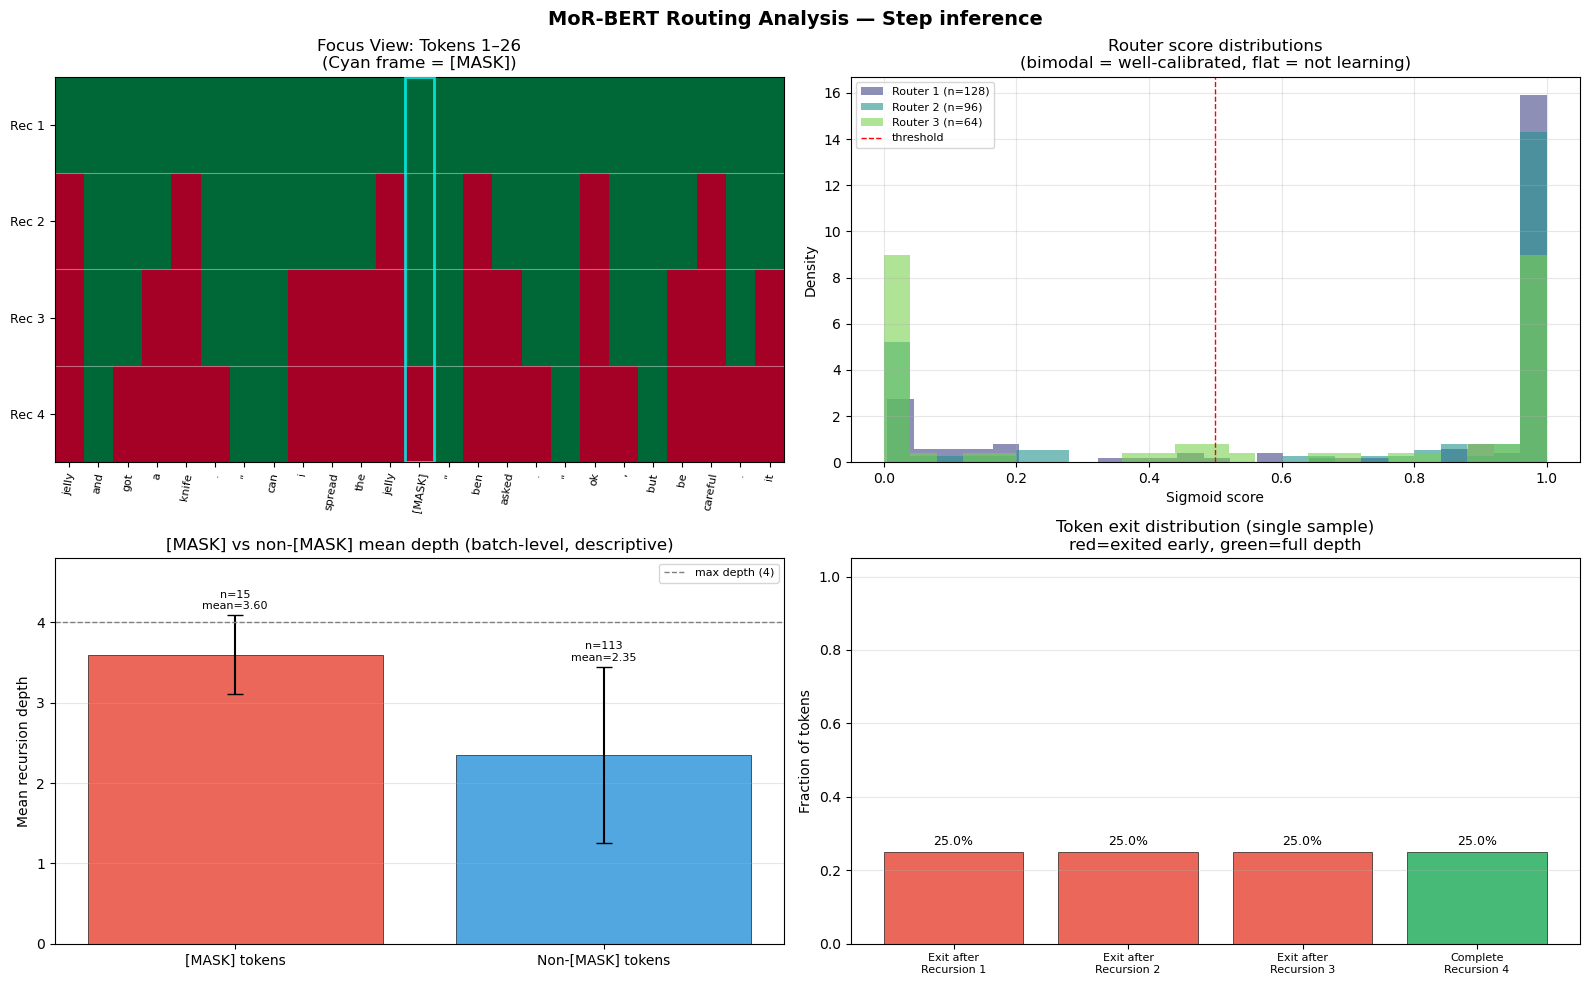

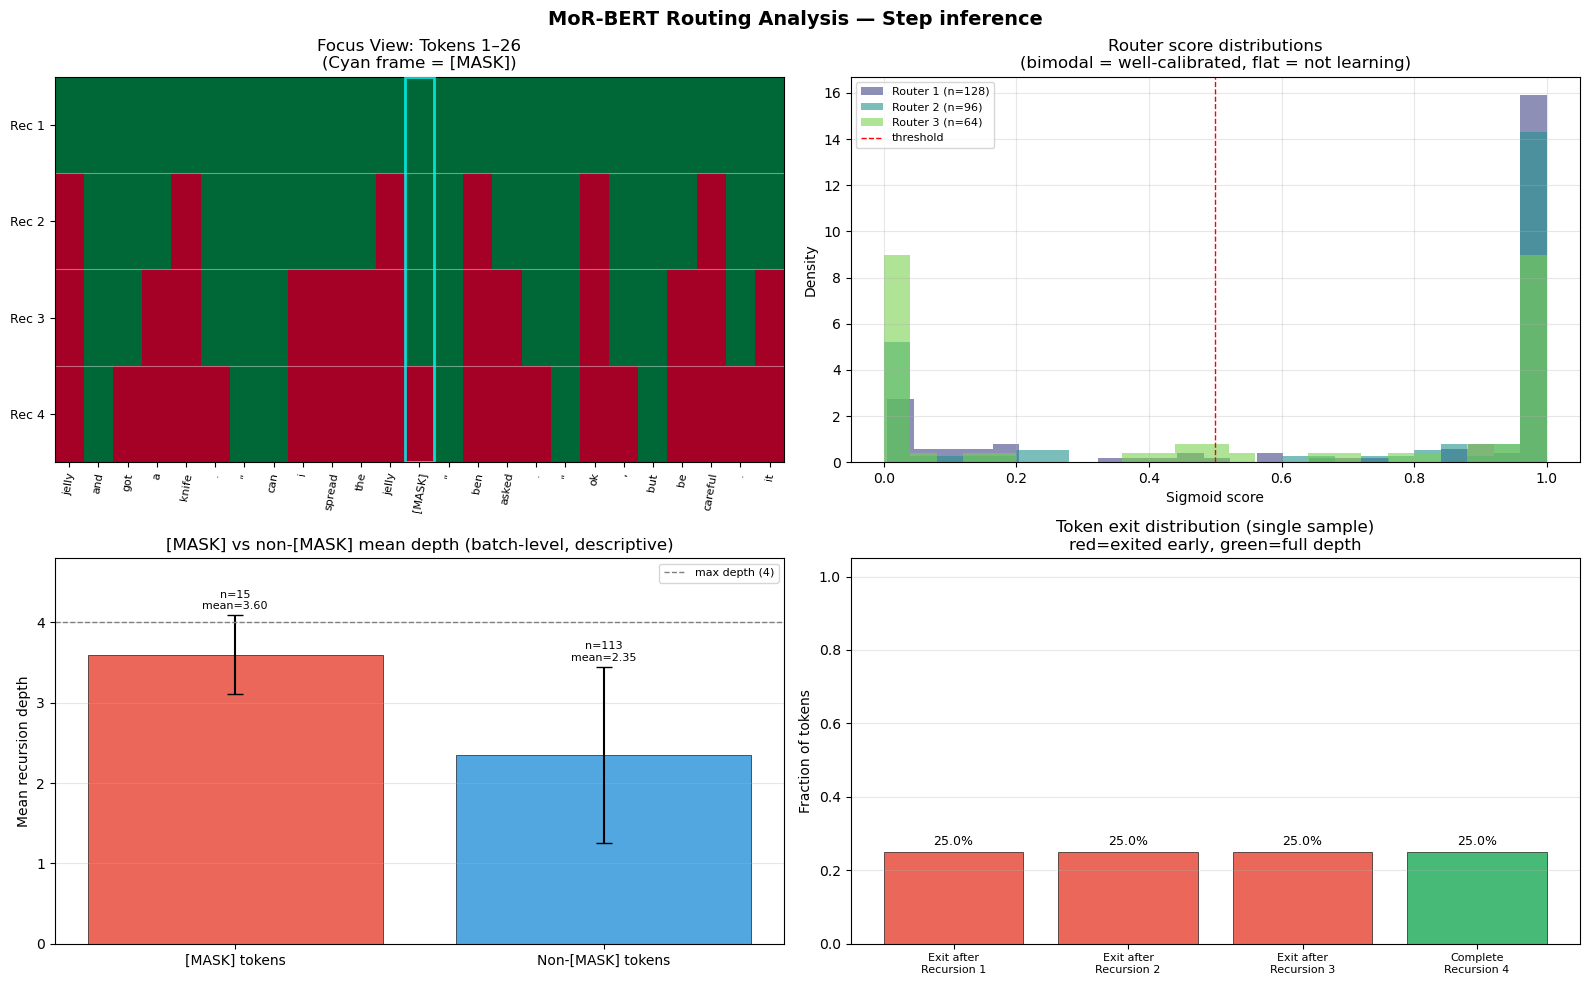

In [ ]:
%matplotlib inline
# Grab a random val sample and run it through the model
def get_val_sample(dataset, model, device, sample_idx=None):
    seq_len = dataset.context_len
    max_idx = len(dataset.val_data) - seq_len - 1
    
    if sample_idx is None:
        sample_idx = np.random.randint(0, max_idx)
    
    # Pull one sequence and add batch dim
    raw = dataset.val_data[sample_idx : sample_idx + seq_len].unsqueeze(0).to(device)
    masked_inputs, labels = dataset.mask_batch(raw)
    
    model.eval()
    with torch.no_grad():
        logits, loss, routing_logs, avg_active_frac = model(masked_inputs, labels=labels)
    
    return masked_inputs, labels, logits, routing_logs

# Run it
masked_inputs, labels, logits, routing_logs = get_val_sample(dataset, mor_model, device)

# Show top-5 predictions for each [MASK] position
mask_positions = (masked_inputs[0] == tokenizer.mask_token_id).nonzero(as_tuple=True)[0]
for mask_idx in mask_positions:
    true_token = tokenizer.decode([labels[0, mask_idx].item()])
    top5 = logits[0, mask_idx].topk(5)
    preds = [(tokenizer.decode([i.item()]), f"{s:.2f}") 
             for s, i in zip(top5.values, top5.indices)]
    print(f"Position {mask_idx}: true='{true_token}' | top5={preds}")

# Plot routing
plot_routing_analysis(routing_logs, tokenizer,
                      masked_inputs, labels,
                      step="inference")

# 03 Inference Benchmark (WIP)

In [ ]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gc

def get_gpu_memory():
    """Get current GPU memory stats in MB."""
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        allocated = torch.cuda.memory_allocated() / 1024**2
        reserved = torch.cuda.memory_reserved() / 1024**2
        return allocated, reserved
    return 0, 0

def measure_model_memory(model, device, batch_size, seq_len, num_passes=5):
    """
    Measure peak memory during forward pass.
    Includes both model params and activation/KV cache.
    """
    torch.cuda.empty_cache()
    gc.collect()
    torch.cuda.reset_peak_memory_stats()
    
    # Get model-only memory (params)
    model_mem_params = sum(p.numel() * p.element_size() for p in model.parameters()) / 1024**2
    
    # Warmup
    dummy = torch.randint(0, 1000, (batch_size, seq_len), device=device)
    with torch.no_grad():
        for _ in range(3):
            _ = model(dummy)
    
    # Measure peak during actual passes
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    
    mem_before = torch.cuda.memory_allocated()
    peak_mems = []
    
    for _ in range(num_passes):
        torch.cuda.reset_peak_memory_stats()
        dummy = torch.randint(0, 1000, (batch_size, seq_len), device=device)
        
        with torch.no_grad():
            _ = model(dummy)
        
        torch.cuda.synchronize()
        peak = torch.cuda.max_memory_allocated() / 1024**2
        peak_mems.append(peak)
    
    avg_peak = np.mean(peak_mems)
    activation_mem = avg_peak - (mem_before / 1024**2) - model_mem_params
    
    return {
        'model_params_mb': model_mem_params,
        'avg_peak_mb': avg_peak,
        'activation_mb': max(0, activation_mem),  # Can be negative due to measurement noise
        'per_token_mb': avg_peak / (batch_size * seq_len),
    }

def benchmark_inference_full(model, dataset, device, name, num_batches=100, warmup=10):
    """
    Comprehensive benchmark: latency, throughput, memory, and MoR-specific metrics.
    """
    model.eval()
    torch.cuda.empty_cache()
    gc.collect()
    
    batch_size = dataset.batch_size
    seq_len = dataset.context_len
    vocab_size = dataset.vocab_size
    
    print(f"\n{'='*50}")
    print(f"Benchmarking: {name}")
    print(f"{'='*50}")
    
    # ===== MEMORY PROFILING =====
    print("Measuring memory footprint...")
    mem_stats = measure_model_memory(model, device, batch_size, seq_len)
    
    print(f"  Model parameters: {mem_stats['model_params_mb']:.1f} MB")
    print(f"  Peak activation:  {mem_stats['activation_mb']:.1f} MB")
    print(f"  Total peak:       {mem_stats['avg_peak_mb']:.1f} MB")
    print(f"  Per-token memory: {mem_stats['per_token_mb']*1024:.2f} KB/token")
    
    # ===== SPEED BENCHMARKING =====
    print(f"\nMeasuring inference speed ({num_batches} batches)...")
    
    # Warmup
    dummy = torch.randint(0, vocab_size, (batch_size, seq_len), device=device)
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(dummy)
    
    # Timing
    times = []
    active_fracs = []
    tokens_per_step = []
    
    train_iter = dataset.get_train_batches(device)
    
    for i in tqdm(range(num_batches), desc=f"[{name}]"):
        try:
            batch_x, _ = next(train_iter)
        except StopIteration:
            train_iter = dataset.get_train_batches(device)
            batch_x, _ = next(train_iter)
        
        # Synchronize and time
        if device.type == 'cuda':
            torch.cuda.synchronize()
        start = time.perf_counter()
        
        with torch.no_grad():
            if isinstance(model, MoRBERT):
                logits, _, routing_logs, avg_active = model(batch_x)
                active_fracs.append(avg_active)
                # Track actual tokens processed (active only)
                total_tokens = batch_x.numel()
                active_tokens = int(total_tokens * avg_active)
                tokens_per_step.append(active_tokens)
            else:
                logits, _, _, _ = model(batch_x)
                tokens_per_step.append(batch_x.numel())
        
        if device.type == 'cuda':
            torch.cuda.synchronize()
        end = time.perf_counter()
        
        times.append((end - start) * 1000)  # ms
    
    times = np.array(times)
    total_time_sec = times.sum() / 1000
    total_tokens = sum(tokens_per_step)
    
    # Calculate throughput in different ways
    wall_throughput = (num_batches * batch_size * seq_len) / total_time_sec  # All positions
    effective_throughput = total_tokens / total_time_sec  # Only active positions (MoR)
    
    results = {
        'name': name,
        'memory': mem_stats,
        'latency_mean_ms': times.mean(),
        'latency_std_ms': times.std(),
        'latency_p50_ms': np.percentile(times, 50),
        'latency_p95_ms': np.percentile(times, 95),
        'latency_p99_ms': np.percentile(times, 99),
        'wall_throughput_tok_s': wall_throughput,  # All token positions
        'effective_throughput_tok_s': effective_throughput,  # Active only
    }
    
    if isinstance(model, MoRBERT) and active_fracs:
        results['avg_active_frac'] = np.mean(active_fracs)
        results['min_active_frac'] = np.min(active_fracs)
        results['max_active_frac'] = np.max(active_fracs)
        # Theoretical: if we could perfectly predict and only run active tokens
        results['theoretical_max_speedup'] = 1.0 / results['avg_active_frac']
        # Actual speedup from effective vs wall throughput
        results['actual_efficiency'] = effective_throughput / wall_throughput
    
    return results, times, tokens_per_step

# Run comprehensive benchmarks
print("="*70)
print("COMPREHENSIVE INFERENCE BENCHMARK: Speed + Memory")
print("="*70)

benchmarks = {}
times_dict = {}

for model, name in [(mor_model, "MoR-BERT"), 
                    (isoparam_model, "IsoParam"), 
                    (isodepth_model, "IsoDepth"),
                    (frozen_kv_trainer.model, "MoR-BERT-FrozenKV")]:
    bench, times, _ = benchmark_inference_full(model, dataset, device, name, 
                                                num_batches=100, warmup=10)
    benchmarks[name] = bench
    times_dict[name] = times

# ===== COMPARISON TABLE =====
print("\n" + "="*70)
print("COMPARISON SUMMARY")
print("="*70)

# Header
print(f"\n{'Model':<12} {'Params(MB)':<11} {'Peak(MB)':<10} {'Lat(ms)':<9} {'Thru(tok/s)':<12} {'Eff(tok/s)':<12}")
print(f"{'':12} {'':11} {'':10} {'(p95)':9} {'(wall)':12} {'(active)':12}")
print("-"*70)

# Rows
baseline_eff = benchmarks['MoR-BERT']['effective_throughput_tok_s']

for name in ['MoR-BERT', 'IsoParam', 'IsoDepth']:
    b = benchmarks[name]
    mem = b['memory']
    
    # Format throughput with speedup indicator
    wall_t = b['wall_throughput_tok_s']
    eff_t = b['effective_throughput_tok_s']
    speedup = eff_t / baseline_eff
    
    print(f"{name:<12} {mem['model_params_mb']:>6.1f}     {mem['avg_peak_mb']:>6.1f}    "
          f"{b['latency_p95_ms']:>6.2f}    {wall_t:>7,.0f}     {eff_t:>7,.0f} {speedup:>4.2f}x")

# MoR-specific analysis
print("\n" + "-"*70)
print("MoR-BERT DYNAMIC ANALYSIS:")
mor = benchmarks['MoR-BERT']
print(f"  Active fraction range: {mor['min_active_frac']:.1%} - {mor['max_active_frac']:.1%}")
print(f"  Average active:         {mor['avg_active_frac']:.1%}")
print(f"  Theoretical max speedup: {mor['theoretical_max_speedup']:.2f}x")
print(f"  Actual efficiency:      {mor['actual_efficiency']:.1%}")
print(f"\nMemory vs IsoDepth:")
depth_mem = benchmarks['IsoDepth']['memory']['avg_peak_mb']
mor_mem = mor['memory']['avg_peak_mb']
print(f"  MoR peak:     {mor_mem:.1f} MB")
print(f"  IsoDepth peak: {depth_mem:.1f} MB")
print(f"  Memory savings: {(depth_mem - mor_mem)/depth_mem:.1%}")
print("-"*70)

# ===== VISUALIZATION =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Inference Benchmark: Speed vs Memory Trade-offs', fontsize=14, fontweight='bold')

colors = {'MoR-BERT': '#e05c2a', 'IsoParam': '#3a7ebf', 'IsoDepth': '#27ae60'}

# Panel 1: Latency distribution
ax = axes[0, 0]
for name, times in times_dict.items():
    ax.hist(times, bins=25, alpha=0.6, label=name, color=colors[name], density=True)
ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Density')
ax.set_title('Latency Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Memory breakdown (stacked bar)
ax = axes[0, 1]
models = list(benchmarks.keys())
x = np.arange(len(models))
width = 0.6

params_mem = [benchmarks[m]['memory']['model_params_mb'] for m in models]
act_mem = [benchmarks[m]['memory']['activation_mb'] for m in models]

bars1 = ax.bar(x, params_mem, width, label='Parameters', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, act_mem, width, bottom=params_mem, label='Activations', color='#e74c3c', alpha=0.8)

ax.set_ylabel('Memory (MB)')
ax.set_title('Memory Footprint Breakdown')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Add total labels
for i, (p, a) in enumerate(zip(params_mem, act_mem)):
    total = p + a
    ax.text(i, total + 10, f'{total:.0f}MB', ha='center', va='bottom', fontsize=9)

# Panel 3: Throughput comparison (wall vs effective for MoR)
ax = axes[1, 0]
metric_names = ['Wall Throughput', 'Effective Throughput']
x = np.arange(len(models))
width = 0.35

wall_vals = [benchmarks[m]['wall_throughput_tok_s'] for m in models]
eff_vals = [benchmarks[m].get('effective_throughput_tok_s', benchmarks[m]['wall_throughput_tok_s']) 
            for m in models]

bars1 = ax.bar(x - width/2, wall_vals, width, label='Wall (all positions)', color='#95a5a6', alpha=0.8)
bars2 = ax.bar(x + width/2, eff_vals, width, label='Effective (active only)', color='#2ecc71', alpha=0.8)

ax.set_ylabel('Throughput (tokens/sec)')
ax.set_title('Throughput: Wall vs Effective')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Panel 4: only plot if trainer histories are available
try:
    accuracies = {
        'MoR-BERT':  max(mor_trainer.history['val_accuracy']),
        'IsoParam':  max(isoparam_trainer.history['val_accuracy']),
        'IsoDepth':  max(isodepth_trainer.history['val_accuracy']),
    }
    for name in models:
        eff = benchmarks[name]['effective_throughput_tok_s']
        mem = benchmarks[name]['memory']['avg_peak_mb']
        acc = accuracies[name]
        ax.scatter(eff, mem, s=acc*500, c=colors[name], alpha=0.6,
                   label=f"{name} ({acc:.1%})", edgecolors='black')
        ax.annotate(f"{acc:.1%}", (eff, mem),
                    textcoords="offset points", xytext=(0,10),
                    ha='center', fontsize=9)
    ax.set_title('Accuracy (bubble size) vs Speed vs Memory')
except NameError:
    ax.text(0.5, 0.5, 'Trainer history not in scope\n(run after training block)',
            ha='center', va='center', transform=ax.transAxes, fontsize=10)
    ax.set_title('Accuracy vs Speed vs Memory (unavailable)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("inference_benchmark_full.png", dpi=150, bbox_inches='tight')
print("\nSaved full benchmark plot → inference_benchmark_full.png")
plt.show()

# ===== KV CACHE ANALYSIS (MoR-specific) =====
if isinstance(mor_model, MoRBERT):
    print("\n" + "="*70)
    print("MoR-BERT KV CACHE ANALYSIS")
    print("="*70)
    
    mor_bench = benchmarks['MoR-BERT']  
    avg_active = mor_bench.get('avg_active_frac', 1.0)
    
    # Correct GQA formula: n_kv_heads * head_dim 
    head_dim = mor_model.dim // mor_model.shared_blocks[0].attn.n_heads
    n_kv_heads = mor_model.shared_blocks[0].attn.n_kv_heads
    kv_dim = n_kv_heads * head_dim  # actual KV width under GQA
    
    full_kv_mb = (dataset.batch_size * dataset.context_len 
                  * kv_dim * 2 * 4) / 1024**2  # K + V, float32
    active_kv_mb = full_kv_mb * avg_active
    
    print("KV cache size scales with active tokens, not full sequence length.")
    print(f"Full seq KV cache:   {full_kv_mb:.3f} MB")
    print(f"Avg active KV cache: {active_kv_mb:.3f} MB  ({avg_active:.1%} of full)")
    print(f"KV memory saving:    {(1 - avg_active):.1%} vs dense")
    print("Note: theoretical only - Python loop implementation doesn't")
    print("      realize wall-clock savings without custom CUDA kernels.")
    print("="*70)

COMPREHENSIVE INFERENCE BENCHMARK: Speed + Memory

Benchmarking: MoR-BERT
Measuring memory footprint...
  Model parameters: 37.0 MB
  Peak activation:  0.0 MB
  Total peak:       753.9 MB
  Per-token memory: 753.90 KB/token

Measuring inference speed (100 batches)...


[MoR-BERT]: 100%|██████████| 100/100 [00:24<00:00,  4.15it/s]



Benchmarking: IsoParam
Measuring memory footprint...
  Model parameters: 37.0 MB
  Peak activation:  0.0 MB
  Total peak:       752.9 MB
  Per-token memory: 752.88 KB/token

Measuring inference speed (100 batches)...


[IsoParam]: 100%|██████████| 100/100 [00:07<00:00, 13.89it/s]



Benchmarking: IsoDepth
Measuring memory footprint...
  Model parameters: 42.2 MB
  Peak activation:  0.0 MB
  Total peak:       752.9 MB
  Per-token memory: 752.88 KB/token

Measuring inference speed (100 batches)...


[IsoDepth]: 100%|██████████| 100/100 [00:09<00:00, 10.56it/s]



Benchmarking: MoR-BERT-FrozenKV
Measuring memory footprint...
  Model parameters: 37.0 MB
  Peak activation:  0.0 MB
  Total peak:       754.7 MB
  Per-token memory: 754.66 KB/token

Measuring inference speed (100 batches)...


[MoR-BERT-FrozenKV]: 100%|██████████| 100/100 [00:25<00:00,  3.91it/s]



COMPARISON SUMMARY

Model        Params(MB)  Peak(MB)   Lat(ms)   Thru(tok/s)  Eff(tok/s)  
                                    (p95)     (wall)       (active)    
----------------------------------------------------------------------
MoR-BERT       37.0      753.9    239.49      4,452       1,948 1.00x
IsoParam       37.0      752.9     60.60     17,310      17,310 8.89x
IsoDepth       42.2      752.9     83.99     12,822      12,822 6.58x

----------------------------------------------------------------------
MoR-BERT DYNAMIC ANALYSIS:
  Active fraction range: 43.8% - 43.8%
  Average active:         43.8%
  Theoretical max speedup: 2.29x
  Actual efficiency:      43.8%

Memory vs IsoDepth:
  MoR peak:     753.9 MB
  IsoDepth peak: 752.9 MB
  Memory savings: -0.1%
----------------------------------------------------------------------


KeyError: 'MoR-BERT-FrozenKV'